# Lesson 132 · Identity-aware message passing: who is asking?

Teacher reference · PROVIDED: inspect; TODO: implement; CHECK: execute; EXIT: defend. Default execution trains two tiny controlled neural variants. It does not run the full RelBench benchmark. No repository files are required.

In [1]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


Actual notebook runtime: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'numpy': '2.5.0', 'pandas': '3.0.3', 'torch': '2.13.0+cpu', 'pytorch-frame': '0.3.0', 'torch-geometric': '2.8.0.post1', 'relbench': '1.1.0'}


In [2]:
import copy, json, sys, time, hashlib, os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch_frame import stype
from torch_frame.data import Dataset
from torch_geometric.data import HeteroData
def rejected(fn):
    try:fn()
    except (ValueError,IndexError):return
    raise AssertionError('Invalid input was silently accepted')

/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 131 to this lesson</p>
<p>The traced stack encodes table type and time. Recommendation also needs to preserve who is asking while scoring candidate entities.</p>
<details><summary>Quick prerequisite reminder</summary><p>A root marker is one shared vector identifying the query role. It differs from a separately learned vector for each global ID. A two-tower model scores source and destination vectors together.</p></details>
</aside>
<!-- sequence-review:end -->



## The question this lesson answers

**How can the same sponsor receive a different representation depending on which condition we are asking about?** In [Lesson 131](https://avistian.github.io/relational/lessons/0131-gnn-tabular-stack.html), you traced rows through encoders, graph layers and a root head. Recommendation changes the question: now one source query must rank many destination entities. We need to preserve who is asking while messages travel through the graph.

Your deliverable is a **variant comparison with a defensible explanation**: trace the root marker, implement labels that retain query ownership, and distinguish a controlled mechanism experiment from a published benchmark comparison. This serves the course mission: determine which relational information a model can use before claiming that its benchmark score demonstrates an advantage.

[Student lab](https://avistian.github.io/relational/labs/0132-identity-aware-message-passing.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0132-identity-aware-message-passing.html) · [Reference](https://avistian.github.io/relational/reference/identity-aware-message-passing.html) · [Reproduction protocol](https://avistian.github.io/relational/labs/l132-reproduction.md)

Recall: when can 1-WL fail? Which index identifies a query owner? Where does the prediction head read?

**Read first.** [You et al., Identity-aware Graph Neural Networks](https://snap.stanford.edu/idgnn/) motivates identity-aware message passing. [RelBench v1 §3, Tables 5/8 and Appendix B.2](https://arxiv.org/html/2407.20060v1) specifies the recommendation experiment. Read the [pinned Model](https://avistian.github.io/relational/labs/sources/l132/model.py) beside these papers: the conceptual family and this implementation are not identical.

**Route.** Spend about 35–45 minutes on the walkthrough and predictions, then complete the three notebook functions. The default notebook executes a small complete neural fixture and its paired ablation. The full-data training gate is separate, uses pinned sources, and writes fresh evidence. Ask the teaching agent about any step you cannot explain without looking at the code.



## 1 · A collision that more ordinary layers cannot resolve

> **In plain terms.** If every node starts the same and always receives the same kinds of messages, it stays the same. More repetitions do not invent a distinguishing signal.

Recall [L088, graph classification](https://avistian.github.io/relational/lessons/0088-graph-classification.html): a message-passing network combines a node’s current vector with a permutation-invariant aggregate of neighbor vectors. The **1-WL test** repeatedly refines node colors using the multiset of neighbor colors. Standard message-passing networks are bounded by this test under the usual feature and aggregation assumptions. This is an expressiveness statement, not a claim that every implemented GNN attains the bound.

**Worked example.** Compare a six-cycle with two disconnected triangles. Both contain six nodes, and every node has degree two. Give every node the scalar feature 1. Use the deliberately simple rule `h_next = A @ h`, where A is the adjacency matrix. After one round every node is 2; after two, 4; after three, 8. More rounds keep the collision. The disconnected example makes the mechanism visible; a particular network may distinguish other graph pairs with richer initial features.

<figure class="stream-figure" tabindex="0">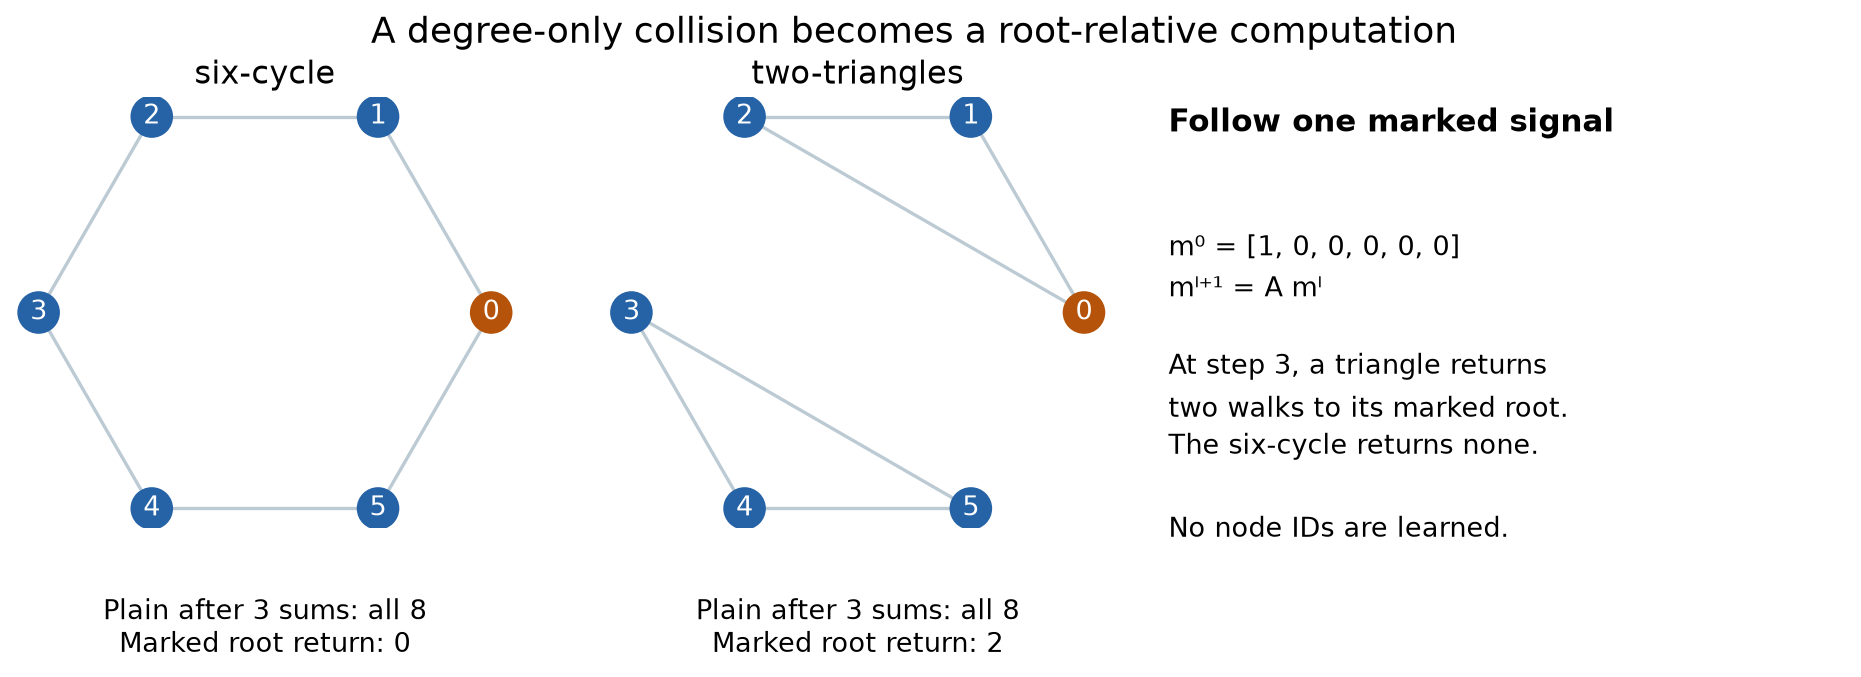<figcaption>Constant-feature sums collide. Three marked propagation steps return zero walks on the six-cycle and two on a triangle. This is a synthetic counting witness.</figcaption></figure>

Now give one chosen root the signal 1 and every other node 0. Propagate that signal by the same sums. After three steps, the root of a triangle receives two returned walks: clockwise and anticlockwise. The root in the six-cycle receives none. Nothing learned a permanent ID for node 0. The computation knows **which node is the current root**.

**Predict before moving the control.** At one step, should the marked root receive anything back? At two steps, can this example distinguish the graphs? Write both answers, then inspect the intermediate node values.

Static check: at depths 1 and 2, both marked roots return 0 and 2 respectively. At depth 3 they diverge: six-cycle 0, triangle 2.

This is a counting witness, not a trained ID-GNN result. It establishes that root-relative information can expose structure erased by the unmarked calculation. It does not establish that a learned model will exploit that information on any particular dataset.



## 2 · Three meanings of identity that must stay separate

A **table type** says what kind of row a node represents: condition, study or sponsor. A **global ID embedding** assigns a separate trainable vector to each known database entity. A **root marker** uses one shared vector to say “this occurrence is the source of this query.” These are three different parameter-sharing decisions.

The original ID-GNN paper assigns different message-function parameters to messages from the root and other nodes inside an ego network. An **ego network** is the neighborhood extracted around a chosen root. The pinned RelBench variant instead adds one learned vector before ordinary typed GraphSAGE propagation. Here **identity-aware message passing (IDMP)** describes the family of root-conditioned computations; it is not a claim that RelBench releases a separate model named IDMP.

**Worked example.** A condition vector is `[2, −1]`; the shared root marker is `[0.5, 0.25]`. Its root occurrence becomes `[2.5, −0.75]`. An occurrence of that same database condition used merely as context keeps `[2, −1]`. The model conditions on the role of the occurrence, not the spelling or numeric magnitude of a primary key.

```text
encoded root occurrences [B,d] + shared marker [1,d]
encoded context occurrences [N−B,d] remain unchanged
```

**TODO 1 — `mark_roots`.** Add the shared `[1,d]` marker to the first B encoded root occurrences. Preserve all context rows, avoid mutating the input tensor, and keep the gradient path. The loader’s root-first convention is part of this function’s contract. If there are B roots, a sum over all output coordinates must send B units of gradient to each marker coordinate.

A table-specific encoder already distinguishes conditions from sponsors. Marking every condition row therefore adds no information about which condition is the query. Likewise, replacing the marker with an embedding lookup changes the model: now every condition ID has separate parameters and unseen IDs need a policy.



### TODO · mark_roots

Implement the contract above; keep the CHECK unchanged. Diagnose failures before reading the reference.

In [3]:
def mark_roots(x, batch_size, marker):
    """Add ONE shared role vector to root occurrences, without mutating encoded inputs."""
    if x.ndim != 2 or marker.shape != (1,x.shape[1]) or not 0 <= batch_size <= len(x):
        raise ValueError('Expected N×d rows, 1×d marker and valid root prefix')
    return torch.cat((x[:batch_size]+marker,x[batch_size:]),dim=0)

In [4]:
def check_marker(fn):
    x=torch.zeros(5,2,requires_grad=True);marker=torch.tensor([[2.,-1.]],requires_grad=True)
    y=fn(x,2,marker)
    torch.testing.assert_close(y,torch.tensor([[2.,-1.],[2.,-1.],[0.,0.],[0.,0.],[0.,0.]]))
    y.sum().backward();torch.testing.assert_close(marker.grad,torch.tensor([[2.,2.]]))
    torch.testing.assert_close(x.detach(),torch.zeros(5,2))
    torch.testing.assert_close(x.grad,torch.ones(5,2))
    rejected(lambda:fn(x,6,marker));rejected(lambda:fn(x,2,torch.ones(1,3)))
check_marker(mark_roots)
print("PASS: mark_roots")

PASS: mark_roots


## 3 · Model architecture: two complete recommendation systems

The selected task asks which sponsors will run trials for a condition during the next 365 days. The released task table contains a condition ID, a cutoff and a set of future sponsor IDs. Those future IDs are supervision; they must not be inserted as prediction-time edges. See the [released SQL task](https://avistian.github.io/relational/labs/sources/l132/trial_task.py).

<figure class="stream-figure" tabindex="0">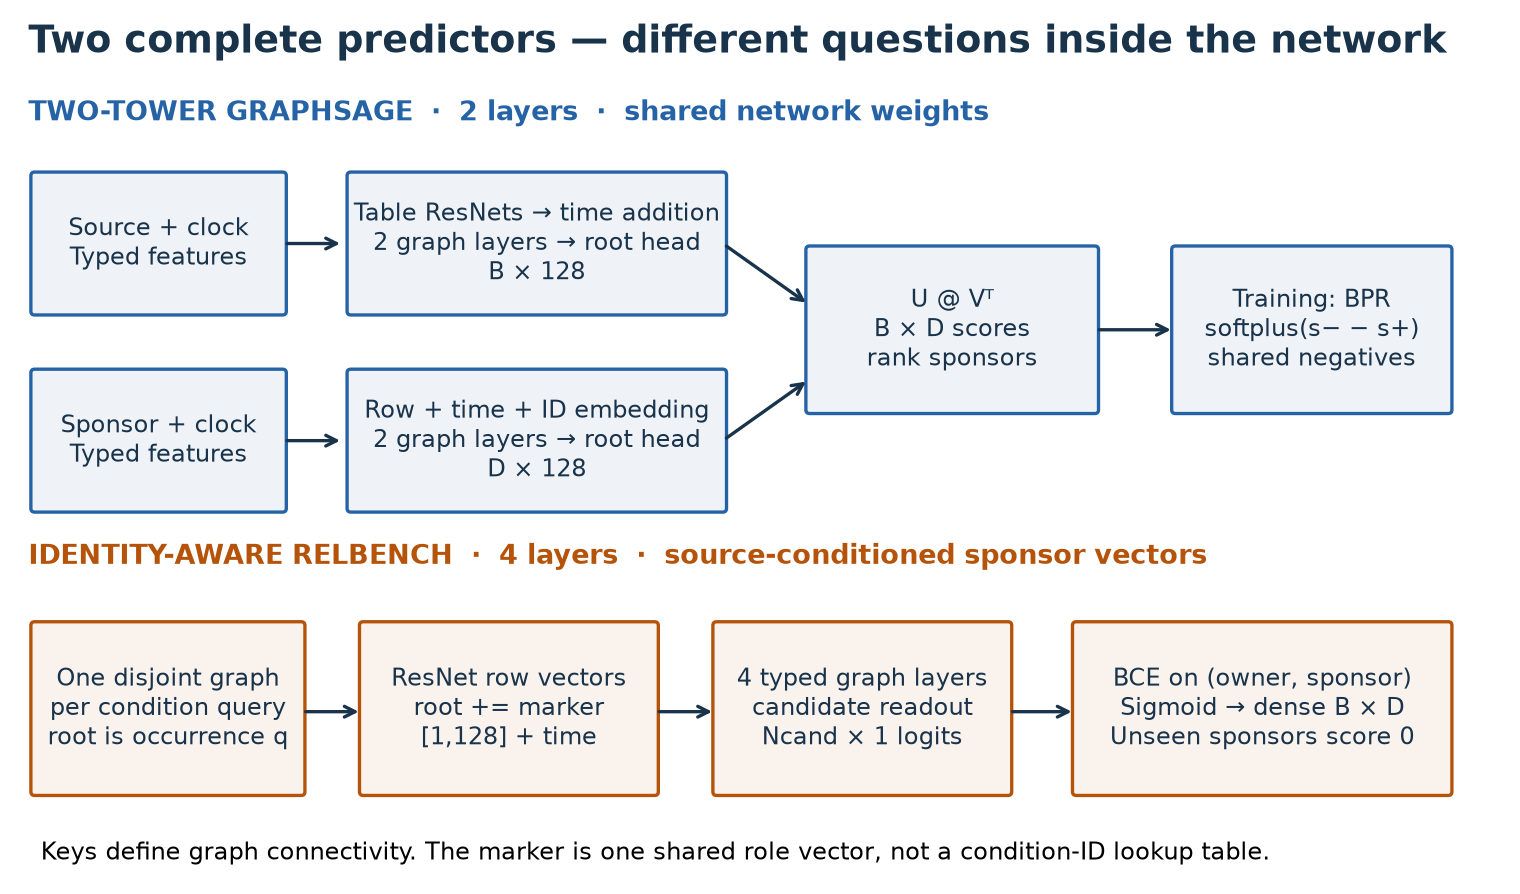<figcaption>Two full predictors: shared two-tower vectors versus query-conditioned sponsor readout. B is query count, D is all sponsors, Ncand is sampled sponsor occurrences. Training objectives and ID embeddings differ.</figcaption></figure>

**Diagram trace.** Compare shared two-tower vectors with source-conditioned candidate vectors. Where is the root marker added, and how is each candidate tied to its query? On a narrow screen, scroll the figure sideways.

### Two-tower GraphSAGE

The network encodes a source neighborhood into a 128-dimensional vector u and a destination neighborhood into a 128-dimensional vector v. Both towers use the same model parameters; the inputs and chosen root table differ. The destination path also adds a trainable embedding for each known sponsor ID in the pinned default. The score is the inner product `u · v`.

At inference, stack B condition vectors as U and D sponsor vectors as V. `U @ V.T` produces a `[B,D]` score matrix. Sponsor vectors can be shared across source queries evaluated at the same cutoff. This is efficient, but a sponsor vector itself does not change with the particular source condition.

**Training.** Bayesian Personalized Ranking (**BPR**) compares a positive sponsor with sampled negatives. The loss is `softplus(negative_score − positive_score)`. The released `share_same_time=True` path shares negative examples among queries at a common time. The purpose is to rank positives above negatives; the score is not automatically a calibrated probability.

The released timestamp sampler drops each timestamp group’s incomplete minibatch. On this task that means 62 × 512 = 31,744 query draws per epoch from the 36,934 available training queries. The omitted subset changes with shuffling. A full released schedule therefore does not mean every training query is visited in every epoch. We preserve this behavior and expose it.

### RelBench’s identity-aware variant

For each condition query, extract a disjoint temporal neighborhood. Encode typed columns into 128-dimensional row vectors. Add the root marker, then query-relative time encodings. Pass messages through four typed GraphSAGE layers. Apply a scalar head to **all sampled sponsor occurrences**, not to the condition root. The sponsor vector is now conditioned on the marked source in its own sampled graph.

**Training.** Each sampled sponsor occurrence gets a binary label defined by its `(query owner, sponsor ID)` pair. Binary cross-entropy (**BCE**) trains its logit. At evaluation, the released implementation initializes a `[B,D]` matrix to zero, writes sigmoid scores for sampled sponsors, and takes the top 10. Unsampled sponsors retain zero. When fewer than ten candidates are scored, zero-score ties can enter the list; preserving this behavior matters for source fidelity.

### Open the identity-aware forward pass

Each relation applies a sum-GraphSAGE transform to neighbor vectors and a transform to the receiving node’s own vector. The implementation sums outputs over incoming relation types, then applies node-wise LayerNorm and ReLU. Repeating these operations transports the root signal along typed paths. The root marker is added once before propagation, not re-added at every layer.

```python
def identity_forward(model,batch,source_type,destination_type,marker_enabled=True):
    """Same ordering as the released forward_dst_readout; only the marker is switchable."""
    if model.id_awareness_emb is None:raise ValueError('Model needs identity awareness')
    seed_time=batch[source_type].seed_time
    x=model.encoder(batch.tf_dict)
    if marker_enabled:x[source_type]=mark_roots(x[source_type],len(seed_time),model.id_awareness_emb.weight)
    time=model.temporal_encoder(seed_time,batch.time_dict,batch.batch_dict)
    for kind,value in time.items():x[kind]=x[kind]+value
    for kind,embedding in model.embedding_dict.items():x[kind]=x[kind]+embedding(batch[kind].n_id)
    x=model.gnn(x,batch.edge_index_dict)
    return model.head(x[destination_type])
```

Read this in execution order. `batch.tf_dict` contains typed table features; `batch.batch_dict` assigns every occurrence to a query clock; `batch.edge_index_dict` supplies typed edges. The return value contains one logit per sampled sponsor occurrence. The same sponsor ID may appear in several rows because each query owns its own computation.

The complete benchmark comparison changes the loss, prediction head, destination embeddings, sampling paths and—on this task—depth. Treat its score difference as a comparison of systems. Section 6 supplies a smaller experiment in which only the marker switch changes.



## 4 · One sponsor, two query owners

> **In plain terms.** “Sponsor 7 is positive” is incomplete. Positive for which condition and cutoff?

A disjoint minibatch repeats database rows as **occurrences** when several queries need them. `n_id` identifies the database row; `batch` identifies the query owning the occurrence. `input_id` maps the query back to its task-table row. These indices are not interchangeable.

**Worked example.** Query 0’s positive set is `{7}`. Query 1’s positive set is `{8}`. The sampled sponsor occurrences are `(0,7), (0,8), (1,7), (1,8)`. Correct labels are `[1,0,0,1]`. Taking membership in the union `{7,8}` instead labels all four positive and trains on false relationships.

<figure class="stream-figure" tabindex="0">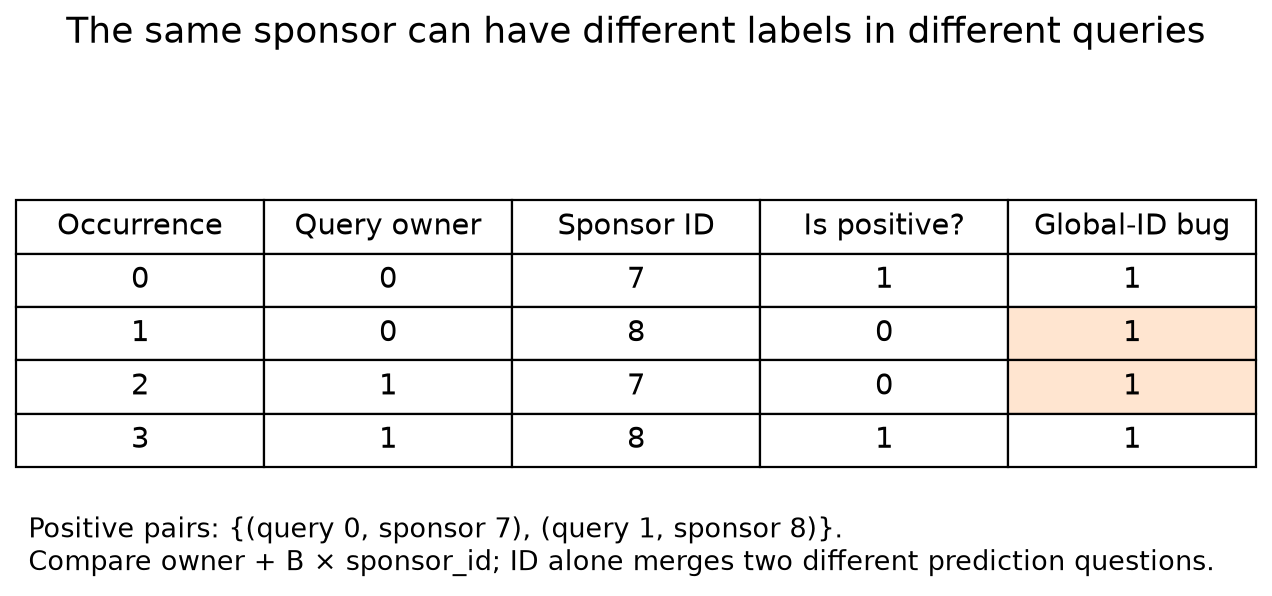<figcaption>Four sponsor occurrences belong to two queries. The global-ID shortcut creates two false positives; pair membership preserves ownership.</figcaption></figure>

The source uses the integer key `owner + B * sponsor_id`. Because owners range from 0 through B−1 and sponsor IDs are nonnegative integers, different pairs have different keys. The batch size is the radix, not the global number of conditions. Integer overflow would invalidate the argument; the tiny indices here and the dataset’s int64 keys stay far below that limit.

**TODO 2 — `candidate_targets`.** Construct query-owned membership labels, validate shapes and owner bounds, and return float labels for BCE. Both the immediate CHECK and the actual small neural training loop call your function.

Static check: correct labels [1,0,0,1]; global-ID labels [1,1,1,1].

Moving a sponsor occurrence between query owners must change its label when the owners’ target sets differ. Renaming sponsor IDs consistently in predictions and truth must leave MAP unchanged. These are useful behavioral tests because they express invariants rather than merely re-running the implementation.



### TODO · candidate_targets

Implement the contract above; keep the CHECK unchanged. Diagnose failures before reading the reference.

In [5]:
def candidate_targets(owner, node_id, positive_owner, positive_id, batch_size):
    """A destination is positive only for its query owner; global ID alone is insufficient."""
    if batch_size <= 0 or owner.shape != node_id.shape or positive_owner.shape != positive_id.shape:
        raise ValueError('Aligned query/node arrays and positive batch size required')
    for a in [owner,positive_owner]:
        if a.ndim!=1 or a.dtype!=torch.long or (a<0).any() or (a>=batch_size).any():
            raise ValueError('Owner index outside current query batch')
    for a in [node_id,positive_id]:
        if a.ndim!=1 or a.dtype!=torch.long or (a<0).any():raise ValueError('Invalid node ID')
    return torch.isin(owner+batch_size*node_id,positive_owner+batch_size*positive_id).float()

In [6]:
def check_targets(fn):
    # Sponsor 7 is positive ONLY for owner 0; same global ID in owner 1 is negative.
    owner=torch.tensor([0,1,0,1]);ids=torch.tensor([7,7,8,9])
    y=fn(owner,ids,torch.tensor([0,1]),torch.tensor([7,9]),2)
    torch.testing.assert_close(y,torch.tensor([1.,0.,0.,1.]))
    rejected(lambda:fn(torch.tensor([2]),torch.tensor([7]),torch.tensor([0]),torch.tensor([7]),2))
check_targets(candidate_targets)
print("PASS: candidate_targets")

PASS: candidate_targets


## 5 · Four layers are a reachability requirement

Why does this ID-GNN use four layers while the two-tower model uses two? A condition and a sponsor are linked through association rows and a study. The condition-centric computation must actually reach a sponsor occurrence before a sponsor head can score it.

<figure class="stream-figure" tabindex="0">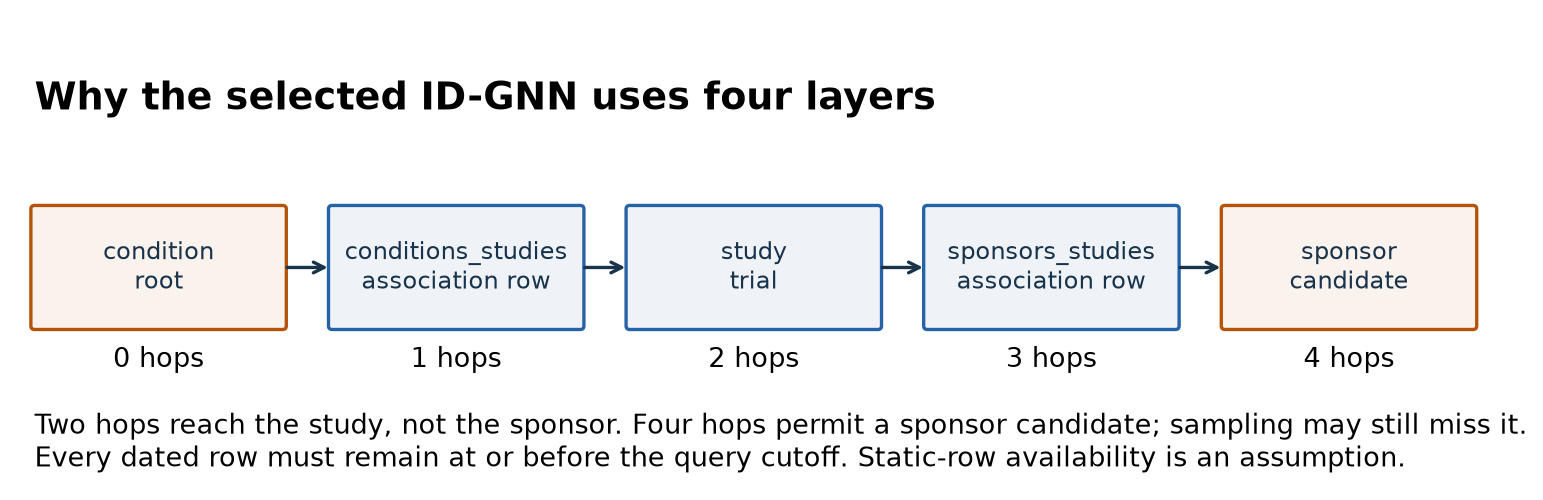<figcaption>The four-hop condition-to-sponsor path crosses two association tables and a study. Hop count permits reachability; sampling and temporal eligibility still matter.</figcaption></figure>

The path is `condition → conditions_studies → study → sponsors_studies → sponsor`. Two layers stop at the study. Four layers make the destination reachable. The two-tower model can encode the condition and sponsor separately and compare their vectors; it does not need a sponsor inside the condition’s sampled graph to form a score.

Reachability is necessary but not sufficient. Fanout sampling may omit a useful route. The released fanouts halve by layer, giving `[128,64,32,16]` for the four-layer path, even though the paper’s table summarizes the neighbor count as 128. The paper specifies uniform temporal sampling; the released ID-GNN CLI defaults to `last`. Our experiment explicitly passes `uniform` and records that choice.

The cutoff belongs to the original query at every hop. A date-filtered path does not establish real ingestion-time validity when arrival timestamps or mutable-row histories are absent. Static tables similarly carry an availability assumption. Root identity does not fix these temporal limitations.

**CHECK your explanation.** If no sponsor is sampled, will adding a larger root marker solve the problem? No: it changes the vector of a present node, not which destination nodes exist in the computation. Increasing depth or changing sampling is a different intervention.



## 6 · A controlled experiment you can execute completely

We construct two disjoint condition queries with four sponsor occurrences. All row features are constant. The root of each query connects to its positive sponsor; a context condition connects to the other sponsor. Without a root marker, the occurrences look the same to the network. With the marker, the network can distinguish the two roles.

This fixture uses the actual released table encoders, temporal encoders, GraphSAGE layers and prediction head. Its 16-dimensional output representation and tiny graph make it a **course experiment**, not the 128-dimensional full-data benchmark. Both arms start from identical weights, use BCE, run 80 epochs, and receive paired dropout random draws.

**Predict.** What probability minimizes BCE when two indistinguishable examples have opposing labels? What loss do you expect near that probability? Commit your answer before reading the measured output.

<figure class="stream-figure" tabindex="0">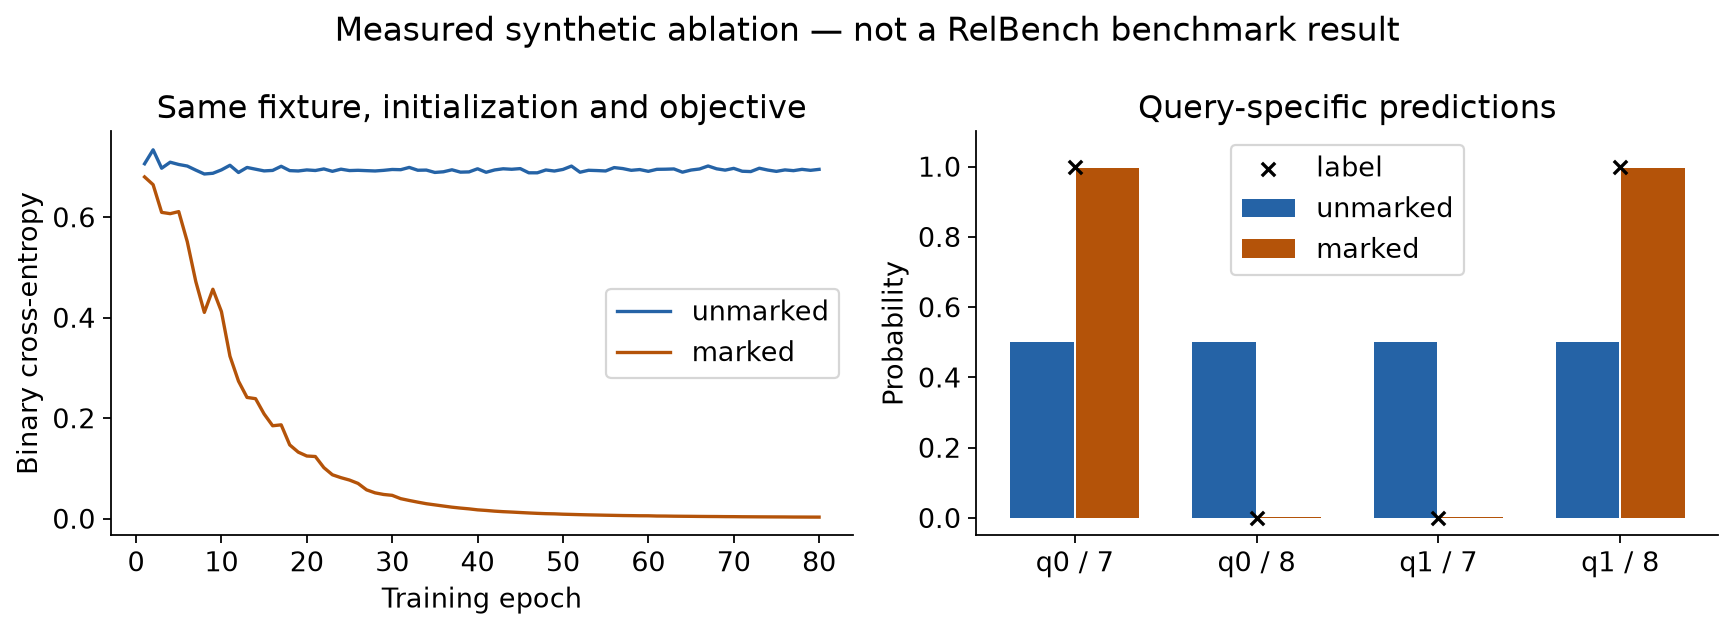<figcaption>Measured tiny neural ablation with identical starting weights, paired random draws and BCE. This is not the published two-tower-versus-ID-GNN experiment.</figcaption></figure>

Measured final training BCE: **0.695164 without the marker**, **0.003021 with the marker**. The parity fixture’s maximum output and gradient discrepancies are both **0**. These are author-reference outputs; your notebook executes the experiment again.

Before fitting, the explicit teaching forward pass is compared with `Model.forward_dst_readout` on the same graph, parameters and random state. Outputs and parameter gradients agree exactly in this CPU fixture. Switching only the marker changes the initialized prediction. Training the two arms then tests whether this particular graph permits the marked model to learn different labels.

**Scope check.** The graph was designed to expose the mechanism. It is not evidence that ID-GNN beats GraphSAGE on a natural benchmark. The unmarked arm here is an ablation of the same BCE architecture, not the two-tower BPR baseline.



## 7 · Score the full task without losing the query

Average precision at k (**AP@k**) rewards placing relevant sponsors early. For a ranked list, sum the precision at each relevant position, then divide by `min(number_of_true_sponsors, k)`. Mean average precision (**MAP@k**) averages AP equally over queries; it does not pool all sponsor occurrences into one classification metric.

**Worked example.** Truth is `{1,4}` and the ranking is `[4,2,1]`. Relevant items appear at ranks 1 and 3. AP@3 is `(1 + 2/3) / 2 = 5/6`. A second query with truth `{3}` and ranking `[2,3,0]` has AP@3 = 1/2. Their MAP is `(5/6 + 1/2)/2 = 2/3`. This is 66.67% when printed in the paper’s percentage units.

**TODO 3 — `mean_average_precision`.** Implement the metric independently. Reject duplicate predictions and misaligned query lists. The selected archive has nonempty ground-truth sets; this function deliberately rejects empty sets rather than silently choosing a convention. The released evaluator filters such queries, so the domain restriction must stay explicit.

The pinned task archive contains 36,934 training, 2,081 validation and 2,057 test queries. The local audit checks query-key uniqueness and nonempty distinct target sets across all rows, and compares independent MAP with the official metric on constructed ranked lists. A second audit independently joins the two raw association tables in SQLite and regenerates all 41,072 query target sets: 503,176 training, 30,448 validation and 25,694 test positive pairs. All sets match the archive. This checks the released label definition; it does not supply missing real-world availability histories.



### TODO · mean_average_precision

Implement the contract above; keep the CHECK unchanged. Diagnose failures before reading the reference.

In [7]:
def mean_average_precision(predictions, positives, k):
    """Independent MAP@k for nonempty query ground truth; one contribution per query."""
    import math
    if k<=0 or len(predictions)!=len(positives) or len(predictions)==0:
        raise ValueError('Nonempty aligned queries and positive k required')
    values=[]
    for ranked,truth in zip(predictions,positives):
        ranked=list(ranked);truth=set(truth)
        if len(ranked)!=k or len(set(ranked))!=k or not truth:
            raise ValueError('Exactly k unique predictions and nonempty truth required')
        hits=0;terms=[]
        for rank,node in enumerate(ranked,1):
            if node in truth:hits+=1;terms.append(hits/rank)
        values.append(math.fsum(terms)/min(k,len(truth)))
    return math.fsum(values)/len(values)

In [8]:
def check_map(fn):
    assert abs(fn([[4,2,1],[2,3,0]],[[1,4],[3]],3)-2/3)<1e-12
    assert fn([[1,2]],[[5]],2)==0
    rejected(lambda:fn([[1,1]],[[1]],2))
    rejected(lambda:fn([[1,2]],[],2))
check_map(mean_average_precision)
print("PASS: mean_average_precision")

PASS: mean_average_precision


## 8 · Reproduce a named experiment, then state its boundary

The target is **RelBench v1 Table 8, rel-trial / condition-sponsor-run**, both RDL variants, five seeds each. Published validation/test MAP percentages are **3.12 / 2.89 for GraphSAGE** and **11.33 / 11.36 for ID-GNN**. The published values are comparison targets, not measurements made by this lesson.

**Selected full experiment: INCOMPLETE.** Measured pilot timing exceeds the per-fit/aggregate budget gate. Full schedules remain executable but were not dispatched under the USD10 cap.

| Pilot | Epochs | Validation MAP % | Test MAP % | Runtime seconds |
|---|---:|---:|---:|---:|
| sage | 1 | 1.6694 | 1.4686 | 154.9 |
| idgnn | 1 | 9.8557 | 10.1469 | 393.8 |

Pilot scores are feasibility evidence, not the five-run, 20-epoch paper result.

[Machine-readable execution summary](https://avistian.github.io/relational/labs/evidence/l132/summary.json). Historical/whole-paper parity remains **NOT_ESTABLISHED**.

The runnable package pins the source commit, archive checksums, text embedding revision, runtime, layer counts, fanouts, objectives and checkpoint selection. It preserves each upstream tie rule: GraphSAGE replaces a checkpoint on `>=`; ID-GNN requires `>`. A run with no selected checkpoint fails visibly. Every completed fit writes predictions keyed by source and cutoff, a checkpoint, per-epoch trace and independent MAP reconciliation.

Preprocessing materializes the released database through its test cap and freezes type inference at seed 42. This is the released workflow’s database-wide preprocessing policy, not a train-only-statistics claim. The original paper’s training commit, seed identities and exact runtime remain unestablished. Even a close numerical result would not prove historical identity or reproduce every experiment in either paper.

**Budget contract.** The aggregate ceiling is $10, including preprocessing, pilots, retries and validation. The operator reserves resources before dispatch, freezes source hashes and refuses the full run unless pilot timing fits the remaining allowance. A complete executable protocol is useful even when its measured execution is incomplete; the status must say which one was delivered. See [exact commands and deviations](https://avistian.github.io/relational/labs/l132-reproduction.md).



## 9 · EXIT: defend the comparison

Submit your notebook and a short comparison containing these five answers:

1. Trace the three-hop marked signal on the two graph shapes. Explain why constant features collide.
2. Explain how one shared root marker differs from a sponsor-ID embedding and a table-specific encoder.
3. Show why `(query 1, sponsor 7)` is negative in the worked minibatch despite sponsor 7 being positive elsewhere.
4. Trace all four relations from a condition to a sponsor. Explain what happens to an unsampled sponsor’s score.
5. Separate the synthetic marker intervention, the named benchmark’s actual execution status, numerical closeness and historical paper parity.

Teach back: explain why the full model comparison changes more than root marking.

Author execution does not complete your EXIT work: **PENDING_WRITTEN_DEFENSE**. If a CHECK passes but you cannot predict the intervention, bring that uncertainty to the teaching agent. Next, L133 will examine the per-relation convolution and the aggregation that combine these messages; L141 will revisit how relational architecture choices use the schema.

<!-- sequence-next:start -->
**Carry this forward.** Open the relation-specific arithmetic that combines all those messages. [Continue to Lesson 133](https://avistian.github.io/relational/lessons/0133-hetero-conv-reg.html).
<!-- sequence-next:end -->


## PROVIDED · the released neural stack

These are the pinned MIT-licensed RelBench modules. Table-specific ResNets, temporal encoders, typed GraphSAGE and both prediction paths are visible. The small experiment uses your root marker and label function.

### PROVIDED · Typed encoders and graph processor

In [9]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict


### PROVIDED · Two full prediction paths

In [10]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[dst_table])


### PROVIDED · Your marker inside the explicit forward pass

In [11]:
def identity_forward(model,batch,source_type,destination_type,marker_enabled=True):
    """Same ordering as the released forward_dst_readout; only the marker is switchable."""
    if model.id_awareness_emb is None:raise ValueError('Model needs identity awareness')
    seed_time=batch[source_type].seed_time
    x=model.encoder(batch.tf_dict)
    if marker_enabled:x[source_type]=mark_roots(x[source_type],len(seed_time),model.id_awareness_emb.weight)
    time=model.temporal_encoder(seed_time,batch.time_dict,batch.batch_dict)
    for kind,value in time.items():x[kind]=x[kind]+value
    for kind,embedding in model.embedding_dict.items():x[kind]=x[kind]+embedding(batch[kind].n_id)
    x=model.gnn(x,batch.edge_index_dict)
    return model.head(x[destination_type])

### PROVIDED · A rooted-walk witness

In [12]:
def cycle_witness():
    """Six-cycle versus two triangles, constant features; root-marked walk returns differ."""
    a=torch.zeros(6,6,dtype=torch.float64);b=torch.zeros_like(a)
    for matrix,cycles in [(a,[list(range(6))]),(b,[[0,1,2],[3,4,5]])]:
        for cycle in cycles:
            for i,u in enumerate(cycle):
                v=cycle[(i+1)%len(cycle)];matrix[u,v]=matrix[v,u]=1
    rows=[]
    for name,adj in [('six-cycle',a),('two-triangles',b)]:
        plain=torch.ones(6,1,dtype=torch.float64)
        marked=mark_roots(torch.zeros_like(plain),1,torch.ones(1,1,dtype=torch.float64))
        trace=[marked[:,0].tolist()]
        for _ in range(3):plain=adj@plain;marked=adj@marked;trace.append(marked[:,0].tolist())
        rows.append(dict(graph=name,plain=plain[:,0].tolist(),marked_steps=trace,root_return=float(marked[0,0])))
    return rows

### PROVIDED · Paired fixture and exact source parity

In [13]:
def neural_fixture():
    torch.set_num_threads(1);torch.manual_seed(132)
    data=HeteroData();stats={}
    for kind in ['conditions','sponsors']:
        table=Dataset(pd.DataFrame({'constant':[1.,1.,1.,1.]}),col_to_stype={'constant':stype.numerical}).materialize()
        data[kind].tf=table.tensor_frame;stats[kind]=table.col_stats
        data[kind].time=torch.tensor([9,9,9,9])
        data[kind].num_nodes=4;data[kind].n_id=torch.tensor([0,1,1,0])
    data['conditions'].batch=torch.tensor([0,1,0,1]);data['conditions'].seed_time=torch.tensor([10,10]);data['conditions'].batch_size=2
    data['sponsors'].batch=torch.tensor([0,0,1,1]);data['sponsors'].n_id=torch.tensor([7,8,7,8])
    edge=torch.tensor([[0,2,3,1],[0,1,2,3]])
    data['conditions','to','sponsors'].edge_index=edge
    data['sponsors','rev','conditions'].edge_index=edge.flip(0)
    original=Model(data,stats,2,16,1,'sum','layer_norm',id_awareness=True)
    reference=copy.deepcopy(original);candidate=copy.deepcopy(original)
    rng=torch.get_rng_state()
    expected=reference.forward_dst_readout(data,'conditions','sponsors')
    torch.set_rng_state(rng)
    actual=identity_forward(candidate,data,'conditions','sponsors')
    torch.testing.assert_close(actual,expected,rtol=0,atol=0)
    expected.sum().backward();actual.sum().backward();max_grad=0.
    for (name,p),(other,q) in zip(reference.named_parameters(),candidate.named_parameters()):
        assert name==other and (p.grad is None)==(q.grad is None)
        if p.grad is not None:
            assert torch.isfinite(p.grad).all() and torch.isfinite(q.grad).all()
            torch.testing.assert_close(p.grad,q.grad,rtol=0,atol=0)
            max_grad=max(max_grad,float((p.grad-q.grad).abs().max()))
    original.eval()
    with torch.no_grad():
        on=identity_forward(original,data,'conditions','sponsors').flatten()
        off=identity_forward(original,data,'conditions','sponsors',False).flatten()
    assert (on-off).abs().max()>1e-6
    torch.testing.assert_close(off,off[0].expand_as(off),atol=1e-6,rtol=1e-6)
    target=candidate_targets(data['sponsors'].batch,data['sponsors'].n_id,torch.tensor([0,1]),torch.tensor([7,8]),2)
    outcomes={}
    for enabled in [False,True]:
        torch.manual_seed(1320)  # Paired dropout draws for both interventions.
        model=copy.deepcopy(original);optimizer=torch.optim.Adam(model.parameters(),lr=.01);trace=[]
        for epoch in range(80):
            model.train();optimizer.zero_grad();logits=identity_forward(model,data,'conditions','sponsors',enabled).flatten()
            loss=torch.nn.functional.binary_cross_entropy_with_logits(logits,target);loss.backward();optimizer.step();trace.append(float(loss.detach()))
        model.eval()
        with torch.no_grad():prob=torch.sigmoid(identity_forward(model,data,'conditions','sponsors',enabled)).flatten()
        outcomes['marked' if enabled else 'unmarked']=dict(probabilities=prob.tolist(),loss=trace[-1],loss_trace=trace)
    assert outcomes['marked']['loss']<.1 and outcomes['unmarked']['loss']>.68
    witness=cycle_witness();assert [x['root_return'] for x in witness]==[0.,2.]
    return dict(status='PASS',source_output_max_error=float((actual-expected).abs().max().detach()),source_gradient_max_error=max_grad,same_state_on=on.tolist(),same_state_off=off.tolist(),targets=target.tolist(),course_fits=outcomes,cycle_witness=witness,scope='Synthetic four-candidate fixture; not a RelBench score',learner_status='PENDING_WRITTEN_DEFENSE')

## CHECK · execute the controlled experiment

Outputs and gradients must match the original path before fitting. The two fitted arms share weights at initialization and random draws. They differ only in marker use.

In [14]:
report=neural_fixture()
Path('l132-report.json').write_text(json.dumps(report,indent=2))
print('Source output/gradient max error:',report['source_output_max_error'],report['source_gradient_max_error'])
print(pd.DataFrame({k:{'BCE':v['loss'],'probabilities':v['probabilities']} for k,v in report['course_fits'].items()}).T)
print('Root returns:',[(x['graph'],x['root_return']) for x in report['cycle_witness']])

Source output/gradient max error: 0.0 0.0
               BCE                                      probabilities
unmarked  0.695164  [0.5017325282096863, 0.5017325282096863, 0.501...
marked    0.003021  [0.997377872467041, 0.003149937139824033, 0.00...
Root returns: [('six-cycle', 0.0), ('two-triangles', 2.0)]


## CHECK · rescore both real-data pilots

These keyed predictions came from the author’s full-data one-epoch GPU pilots. Your metric scores every validation/test query for both systems. This is evidence replay, not fresh training; it cannot establish seed uncertainty or the five-seed paper result.

In [15]:
# Author-reference predictions: independent rescoring, not a fresh benchmark fit.
import base64,io,hashlib,zlib
# Compressed JSON keeps notebook parsing bounded; verify before decoding.
payload_bytes=zlib.decompress(base64.b64decode("""
...
138AX2mJUA==
"""))
assert hashlib.sha256(payload_bytes).hexdigest()=='cdd0b55d3ceca6c139ce5cde9a08933ce31ff0cd114c844a22da55a173bb6bca'
payload=json.loads(payload_bytes)
pilot_payload,truth_payload=payload['pilot'],payload['truth']
pilot_rows=[];rankings=0
for variant,item in pilot_payload.items():
    raw=base64.b64decode(item['base64']);assert hashlib.sha256(raw).hexdigest()==item['sha256']
    saved=np.load(io.BytesIO(raw))
    for split,truth in truth_payload.items():
        np.testing.assert_array_equal(saved[split+'_source'],truth['source'])
        np.testing.assert_array_equal(saved[split+'_time'],truth['time'])
        assert len(set(zip(truth['source'],truth['time'])))==len(truth['source'])
        value=mean_average_precision(saved[split+'_pred'],truth['truth'],10)
        assert abs(value-item['result']['scores'][split])<1e-12
        pilot_rows.append({'variant':variant,'split':split,'pilot_MAP_percent':100*value,'queries':len(truth['source'])})
        rankings+=len(truth['source'])
assert rankings==8276
report['pilot_rankings_rescored']=rankings
Path('l132-report.json').write_text(json.dumps(report,indent=2))
print(pd.DataFrame(pilot_rows).to_string(index=False))
print('8276 author pilot rankings checked with YOUR MAP function. Full training was not run here.')


variant split  pilot_MAP_percent  queries
   sage   val           1.669450     2081
   sage  test           1.468637     2057
  idgnn   val           9.855707     2081
  idgnn  test          10.146937     2057
8276 author pilot rankings checked with YOUR MAP function. Full training was not run here.


## PROVIDED · full reproduction sources and trainer

The following named strings contain complete executable upstream files, not model pseudocode. The gate writes them to an isolated directory. Read `train`, `test`, and the checkpoint-selection block in both runners; they implement different objectives. Source/data checksums and deviations are in the linked reproduction contract.

### RelBench source license

```text
The MIT License (MIT)

Copyright (c) 2023 RelBench Team

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
THE SOFTWARE.

```

In [16]:
full_sources = {}

### Pinned source · l132/utils.py

In [17]:
full_sources['l132/utils.py'] = 'from typing import Any, Dict\n\nimport numpy as np\nimport pandas as pd\nfrom torch_frame import stype\nfrom torch_frame.utils import infer_df_stype\n\nfrom relbench.base import Database, Table\n\n\ndef to_unix_time(ser: pd.Series) -> np.ndarray:\n    r"""Converts a :class:`pandas.Timestamp` series to UNIX timestamp (in seconds)."""\n    assert ser.dtype in [np.dtype("datetime64[s]"), np.dtype("datetime64[ns]")]\n    unix_time = ser.astype("int64").values\n    if ser.dtype == np.dtype("datetime64[ns]"):\n        unix_time //= 10**9\n    return unix_time\n\n\ndef remove_pkey_fkey(col_to_stype: Dict[str, Any], table: Table) -> dict:\n    r"""Remove pkey, fkey columns since they will not be used as input feature."""\n    if table.pkey_col is not None:\n        if table.pkey_col in col_to_stype:\n            col_to_stype.pop(table.pkey_col)\n    for fkey in table.fkey_col_to_pkey_table.keys():\n        if fkey in col_to_stype:\n            col_to_stype.pop(fkey)\n\n\ndef get_stype_proposal(db: Database) -> Dict[str, Dict[str, stype]]:\n    r"""Propose stype for columns of a set of tables in the given database.\n\n    Args:\n        db (Database): The database object containing a set of tables.\n\n    Returns:\n        Dict[str, Dict[str, Any]]: A dictionary mapping table name into\n            :obj:`col_to_stype` (mapping column names into inferred stypes).\n    """\n\n    inferred_col_to_stype_dict = {}\n    for table_name, table in db.table_dict.items():\n        df = table.df\n        df = df.sample(min(1_000, len(df)))\n        inferred_col_to_stype = infer_df_stype(df)\n        # Hack for now. This is relevant for rel-amazon.\n        for col, stype_ in inferred_col_to_stype.items():\n            if stype_.value == "embedding":\n                inferred_col_to_stype[col] = stype.multicategorical\n        inferred_col_to_stype_dict[table_name] = inferred_col_to_stype\n\n    return inferred_col_to_stype_dict\n'

### Pinned source · l132/trial_task.py

In [18]:
full_sources['l132/trial_task.py'] = 'import duckdb\nimport pandas as pd\n\nfrom relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType\nfrom relbench.metrics import (\n    accuracy,\n    average_precision,\n    f1,\n    link_prediction_map,\n    link_prediction_precision,\n    link_prediction_recall,\n    mae,\n    r2,\n    rmse,\n    roc_auc,\n)\n\n\nclass StudyOutcomeTask(EntityTask):\n    r"""Predict if the trials in the next 1 year will achieve its primary outcome."""\n\n    task_type = TaskType.BINARY_CLASSIFICATION\n    entity_col = "nct_id"\n    entity_table = "studies"\n    time_col = "timestamp"\n    target_col = "outcome"\n    timedelta = pd.Timedelta(days=365)\n    metrics = [average_precision, accuracy, f1, roc_auc]\n\n    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:\n        timestamp_df = pd.DataFrame({"timestamp": timestamps})\n        studies = db.table_dict["studies"].df\n        outcomes = db.table_dict["outcomes"].df\n        outcome_analyses = db.table_dict["outcome_analyses"].df\n\n        df = duckdb.sql(\n            f"""\n            WITH TRIAL_INFO AS (\n                SELECT\n                    oa.nct_id,\n                    oa.p_value,\n                    s.start_date,\n                    oa.date\n                FROM outcome_analyses oa\n                LEFT JOIN outcomes o\n                ON oa.outcome_id = o.id\n                LEFT JOIN studies s\n                ON s.nct_id = o.nct_id\n                where (oa.p_value_modifier is null or oa.p_value_modifier != \'>\')\n                and oa.p_value >=0\n                and oa.p_value <=1\n                and o.outcome_type = \'Primary\'\n            )\n\n            SELECT\n                t.timestamp,\n                tr.nct_id,\n                CASE\n                    WHEN MIN(tr.p_value) <= 0.05 THEN 1\n                    ELSE 0\n                END AS outcome\n            FROM timestamp_df t\n            LEFT JOIN TRIAL_INFO tr\n            ON tr.start_date <= t.timestamp\n                and tr.date > t.timestamp\n                and tr.date <= t.timestamp + INTERVAL \'{self.timedelta}\'\n            WHERE tr.nct_id is not null\n            GROUP BY t.timestamp, tr.nct_id;\n            """\n        ).df()\n\n        return Table(\n            df=df,\n            fkey_col_to_pkey_table={self.entity_col: self.entity_table},\n            pkey_col=None,\n            time_col=self.time_col,\n        )\n\n\nclass StudyAdverseTask(EntityTask):\n    r"""Predict the number of affected patients with severe advsere events/death for the\n    trial in the next 1 year."""\n\n    task_type = TaskType.REGRESSION\n    entity_col = "nct_id"\n    entity_table = "studies"\n    time_col = "timestamp"\n    target_col = "num_of_adverse_events"\n    timedelta = pd.Timedelta(days=365)\n    metrics = [r2, mae, rmse]\n\n    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:\n        timestamp_df = pd.DataFrame({"timestamp": timestamps})\n        reported_event_totals = db.table_dict["reported_event_totals"].df\n        studies = db.table_dict["studies"].df\n\n        df = duckdb.sql(\n            f"""\n            WITH TRIAL_INFO AS (\n                SELECT\n                    r.nct_id,\n                    r.event_type,\n                    r.subjects_affected,\n                    r.date,\n                    s.start_date\n                FROM reported_event_totals r\n                LEFT JOIN studies s\n                ON r.nct_id = s.nct_id\n                WHERE r.event_type = \'serious\' or r.event_type = \'deaths\'\n                and r.subjects_affected is not null\n            )\n\n            SELECT\n                t.timestamp,\n                tr.nct_id,\n                sum(tr.subjects_affected) AS num_of_adverse_events\n            FROM timestamp_df t\n            LEFT JOIN TRIAL_INFO tr\n            ON tr.start_date <= t.timestamp\n                and tr.date > t.timestamp\n                and tr.date <= t.timestamp + INTERVAL \'{self.timedelta}\'\n            WHERE tr.nct_id is not null and tr.subjects_affected is not null\n            GROUP BY t.timestamp, tr.nct_id;\n            """\n        ).df()\n\n        return Table(\n            df=df,\n            fkey_col_to_pkey_table={self.entity_col: self.entity_table},\n            pkey_col=None,\n            time_col=self.time_col,\n        )\n\n\nclass SiteSuccessTask(EntityTask):\n    r"""Predict the success rate of a trial site in the next 1 year."""\n\n    task_type = TaskType.REGRESSION\n    entity_col = "facility_id"\n    entity_table = "facilities"\n    time_col = "timestamp"\n    target_col = "success_rate"\n    timedelta = pd.Timedelta(days=365)\n    metrics = [r2, mae, rmse]\n\n    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:\n        timestamp_df = pd.DataFrame({"timestamp": timestamps})\n        facilities = db.table_dict["facilities"].df\n        facility_study = db.table_dict["facilities_studies"].df\n        outcome_analyses = db.table_dict["outcome_analyses"].df\n        studies = db.table_dict["studies"].df\n        outcomes = db.table_dict["outcomes"].df\n\n        df = duckdb.sql(\n            f"""\n            WITH TRIAL_INFO AS (\n                SELECT\n                    oa.nct_id,\n                    MIN(CASE WHEN oa.p_value < 0.05 THEN 1 ELSE 0 END) AS is_successful, -- Determine if the trial is successful\n                    oa.date,\n                FROM outcome_analyses oa\n                LEFT JOIN outcomes o\n                ON oa.outcome_id = o.id\n                WHERE (oa.p_value_modifier is null or oa.p_value_modifier != \'>\')\n                and oa.p_value >=0\n                and oa.p_value <=1\n                and o.outcome_type = \'Primary\'\n                GROUP BY oa.nct_id, oa.date\n            )\n\n            SELECT\n                t.timestamp,\n                fs.facility_id,\n                SUM(tr.is_successful)/COUNT(tr.is_successful) AS success_rate\n            FROM timestamp_df t\n            LEFT JOIN TRIAL_INFO tr\n            LEFT JOIN facility_study fs ON fs.nct_id = tr.nct_id\n            ON tr.date > t.timestamp\n                and tr.date <= t.timestamp + INTERVAL \'{self.timedelta}\'\n            WHERE fs.facility_id is not null\n            GROUP BY t.timestamp, fs.facility_id;\n            """\n        ).df()\n\n        return Table(\n            df=df,\n            fkey_col_to_pkey_table={self.entity_col: self.entity_table},\n            pkey_col=None,\n            time_col=self.time_col,\n        )\n\n\nclass ConditionSponsorRunTask(RecommendationTask):\n    r"""Predict whether this condition will have which sponsors."""\n\n    task_type = TaskType.LINK_PREDICTION\n    src_entity_col = "condition_id"\n    src_entity_table = "conditions"\n    dst_entity_col = "sponsor_id"\n    dst_entity_table = "sponsors"\n    time_col = "timestamp"\n    timedelta = pd.Timedelta(days=365)\n    metrics = [link_prediction_precision, link_prediction_recall, link_prediction_map]\n    eval_k = 10\n\n    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:\n        timestamp_df = pd.DataFrame({"timestamp": timestamps})\n        sponsors_studies = db.table_dict["sponsors_studies"].df\n        condition_study = db.table_dict["conditions_studies"].df\n\n        df = duckdb.sql(\n            f"""\n            SELECT\n                t.timestamp,\n                cs.condition_id,\n                LIST(DISTINCT ss.sponsor_id) AS sponsor_id\n            FROM timestamp_df t\n            LEFT JOIN condition_study cs\n            LEFT JOIN sponsors_studies ss ON ss.nct_id = cs.nct_id\n            ON cs.date > t.timestamp\n                and cs.date <= t.timestamp + INTERVAL \'{self.timedelta}\'\n            GROUP BY t.timestamp, cs.condition_id;\n            """\n        ).df()\n\n        return Table(\n            df=df,\n            fkey_col_to_pkey_table={\n                self.src_entity_col: self.src_entity_table,\n                self.dst_entity_col: self.dst_entity_table,\n            },\n            pkey_col=None,\n            time_col=self.time_col,\n        )\n\n\nclass SiteSponsorRunTask(RecommendationTask):\n    r"""Predict whether this sponsor will have a trial in a facility."""\n\n    task_type = TaskType.LINK_PREDICTION\n    src_entity_col = "facility_id"\n    src_entity_table = "facilities"\n    dst_entity_col = "sponsor_id"\n    dst_entity_table = "sponsors"\n    time_col = "timestamp"\n    timedelta = pd.Timedelta(days=365)\n    metrics = [link_prediction_precision, link_prediction_recall, link_prediction_map]\n    eval_k = 10\n\n    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:\n        timestamp_df = pd.DataFrame({"timestamp": timestamps})\n        sponsors_studies = db.table_dict["sponsors_studies"].df\n        facility_study = db.table_dict["facilities_studies"].df\n\n        df = duckdb.sql(\n            f"""\n            SELECT\n                t.timestamp,\n                fs.facility_id,\n                LIST(DISTINCT ss.sponsor_id) AS sponsor_id\n            FROM timestamp_df t\n            LEFT JOIN facility_study fs\n            LEFT JOIN sponsors_studies ss ON ss.nct_id = fs.nct_id\n            ON fs.date > t.timestamp\n                and fs.date <= t.timestamp + INTERVAL \'{self.timedelta}\'\n            GROUP BY t.timestamp, fs.facility_id;\n            """\n        ).df()\n\n        return Table(\n            df=df,\n            fkey_col_to_pkey_table={\n                self.src_entity_col: self.src_entity_table,\n                self.dst_entity_col: self.dst_entity_table,\n            },\n            pkey_col=None,\n            time_col=self.time_col,\n        )\n'

### Pinned source · l132/gnn_link.py

In [19]:
full_sources['l132/gnn_link.py'] = 'import argparse\nimport copy\nimport json\nimport os\nimport warnings\nfrom pathlib import Path\nfrom typing import Dict, Tuple\n\nimport numpy as np\nimport torch\nimport torch.nn.functional as F\nfrom model import Model\nfrom text_embedder import GloveTextEmbedding\nfrom torch import Tensor\nfrom torch_frame import stype\nfrom torch_frame.config.text_embedder import TextEmbedderConfig\nfrom torch_geometric.loader import NeighborLoader\nfrom torch_geometric.seed import seed_everything\nfrom tqdm import tqdm\n\nfrom relbench.base import Dataset, RecommendationTask, TaskType\nfrom relbench.datasets import get_dataset\nfrom relbench.modeling.graph import get_link_train_table_input, make_pkey_fkey_graph\nfrom relbench.modeling.loader import LinkNeighborLoader\nfrom relbench.modeling.utils import get_stype_proposal\nfrom relbench.tasks import get_task\n\nparser = argparse.ArgumentParser()\nparser.add_argument("--dataset", type=str, default="rel-hm")\nparser.add_argument("--task", type=str, default="user-item-purchase")\nparser.add_argument("--lr", type=float, default=0.001)\nparser.add_argument("--epochs", type=int, default=20)\nparser.add_argument("--eval_epochs_interval", type=int, default=1)\nparser.add_argument("--batch_size", type=int, default=512)\nparser.add_argument("--channels", type=int, default=128)\nparser.add_argument("--aggr", type=str, default="sum")\nparser.add_argument("--num_layers", type=int, default=2)\nparser.add_argument("--num_neighbors", type=int, default=128)\nparser.add_argument("--temporal_strategy", type=str, default="uniform")\n# Use the same seed time across the mini-batch and share the negatives\nparser.add_argument("--share_same_time", action="store_true", default=True)\nparser.add_argument(\n    "--no-share_same_time", dest="share_same_time", action="store_false"\n)\n# Whether to use shallow embedding on dst nodes or not.\nparser.add_argument("--use_shallow", action="store_true", default=True)\nparser.add_argument("--no-use_shallow", dest="use_shallow", action="store_false")\nparser.add_argument("--max_steps_per_epoch", type=int, default=2000)\nparser.add_argument("--num_workers", type=int, default=0)\nparser.add_argument("--seed", type=int, default=42)\nparser.add_argument(\n    "--cache_dir",\n    type=str,\n    default=os.path.expanduser("~/.cache/relbench_examples"),\n)\nargs = parser.parse_args()\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nif torch.cuda.is_available():\n    torch.set_num_threads(1)\nseed_everything(args.seed)\n\ndataset: Dataset = get_dataset(args.dataset, download=True)\ntask: RecommendationTask = get_task(args.dataset, args.task, download=True)\ntune_metric = "link_prediction_map"\nassert task.task_type == TaskType.LINK_PREDICTION\n\nstypes_cache_path = Path(f"{args.cache_dir}/{args.dataset}/stypes.json")\ntry:\n    with open(stypes_cache_path, "r") as f:\n        col_to_stype_dict = json.load(f)\n    for table, col_to_stype in col_to_stype_dict.items():\n        for col, stype_str in col_to_stype.items():\n            col_to_stype[col] = stype(stype_str)\nexcept FileNotFoundError:\n    col_to_stype_dict = get_stype_proposal(dataset.get_db())\n    Path(stypes_cache_path).parent.mkdir(parents=True, exist_ok=True)\n    with open(stypes_cache_path, "w") as f:\n        json.dump(col_to_stype_dict, f, indent=2, default=str)\n\ndata, col_stats_dict = make_pkey_fkey_graph(\n    dataset.get_db(),\n    col_to_stype_dict=col_to_stype_dict,\n    text_embedder_cfg=TextEmbedderConfig(\n        text_embedder=GloveTextEmbedding(device=device), batch_size=256\n    ),\n    cache_dir=f"{args.cache_dir}/{args.dataset}/materialized",\n)\n\nnum_neighbors = [int(args.num_neighbors // 2**i) for i in range(args.num_layers)]\n\ntrain_table_input = get_link_train_table_input(task.get_table("train"), task)\ntrain_loader = LinkNeighborLoader(\n    data=data,\n    num_neighbors=num_neighbors,\n    time_attr="time",\n    src_nodes=train_table_input.src_nodes,\n    dst_nodes=train_table_input.dst_nodes,\n    num_dst_nodes=train_table_input.num_dst_nodes,\n    src_time=train_table_input.src_time,\n    share_same_time=args.share_same_time,\n    batch_size=args.batch_size,\n    temporal_strategy=args.temporal_strategy,\n    # if share_same_time is True, we use sampler, so shuffle must be set False\n    shuffle=not args.share_same_time,\n    num_workers=args.num_workers,\n)\n\neval_loaders_dict: Dict[str, Tuple[NeighborLoader, NeighborLoader]] = {}\nfor split in ["val", "test"]:\n    timestamp = dataset.val_timestamp if split == "val" else dataset.test_timestamp\n    seed_time = int(timestamp.timestamp())\n    target_table = task.get_table(split)\n    src_node_indices = torch.from_numpy(target_table.df[task.src_entity_col].values)\n    src_loader = NeighborLoader(\n        data,\n        num_neighbors=num_neighbors,\n        time_attr="time",\n        input_nodes=(task.src_entity_table, src_node_indices),\n        input_time=torch.full(\n            size=(len(src_node_indices),), fill_value=seed_time, dtype=torch.long\n        ),\n        batch_size=args.batch_size,\n        shuffle=False,\n        num_workers=args.num_workers,\n    )\n    dst_loader = NeighborLoader(\n        data,\n        num_neighbors=num_neighbors,\n        time_attr="time",\n        input_nodes=task.dst_entity_table,\n        input_time=torch.full(\n            size=(task.num_dst_nodes,), fill_value=seed_time, dtype=torch.long\n        ),\n        batch_size=args.batch_size,\n        shuffle=False,\n        num_workers=args.num_workers,\n    )\n    eval_loaders_dict[split] = (src_loader, dst_loader)\n\nmodel = Model(\n    data=data,\n    col_stats_dict=col_stats_dict,\n    num_layers=args.num_layers,\n    channels=args.channels,\n    out_channels=args.channels,\n    aggr=args.aggr,\n    norm="layer_norm",\n    shallow_list=[task.dst_entity_table] if args.use_shallow else [],\n).to(device)\noptimizer = torch.optim.Adam(model.parameters(), lr=args.lr)\n\n\ndef train() -> float:\n    model.train()\n\n    loss_accum = count_accum = 0\n    steps = 0\n    total_steps = min(len(train_loader), args.max_steps_per_epoch)\n    for batch in tqdm(train_loader, total=total_steps):\n        src_batch, batch_pos_dst, batch_neg_dst = batch\n        src_batch, batch_pos_dst, batch_neg_dst = (\n            src_batch.to(device),\n            batch_pos_dst.to(device),\n            batch_neg_dst.to(device),\n        )\n        x_src = model(src_batch, task.src_entity_table)\n        x_pos_dst = model(batch_pos_dst, task.dst_entity_table)\n        x_neg_dst = model(batch_neg_dst, task.dst_entity_table)\n\n        # [batch_size, ]\n        pos_score = torch.sum(x_src * x_pos_dst, dim=1)\n        if args.share_same_time:\n            # [batch_size, batch_size]\n            neg_score = x_src @ x_neg_dst.t()\n            # [batch_size, 1]\n            pos_score = pos_score.view(-1, 1)\n        else:\n            # [batch_size, ]\n            neg_score = torch.sum(x_src * x_neg_dst, dim=1)\n        optimizer.zero_grad()\n        # BPR loss\n        diff_score = pos_score - neg_score\n        loss = F.softplus(-diff_score).mean()\n        loss.backward()\n        optimizer.step()\n\n        loss_accum += float(loss) * x_src.size(0)\n        count_accum += x_src.size(0)\n\n        steps += 1\n        if steps > args.max_steps_per_epoch:\n            break\n\n    if count_accum == 0:\n        warnings.warn(\n            f"Did not sample a single \'{task.dst_entity_table}\' "\n            f"node in any mini-batch. Try to increase the number "\n            f"of layers/hops and re-try. If you run into memory "\n            f"issues with deeper nets, decrease the batch size."\n        )\n\n    return loss_accum / count_accum if count_accum > 0 else float("nan")\n\n\n@torch.no_grad()\ndef test(src_loader: NeighborLoader, dst_loader: NeighborLoader) -> np.ndarray:\n    model.eval()\n\n    dst_embs: list[Tensor] = []\n    for batch in tqdm(dst_loader):\n        batch = batch.to(device)\n        emb = model(batch, task.dst_entity_table).detach()\n        dst_embs.append(emb)\n    dst_emb = torch.cat(dst_embs, dim=0)\n    del dst_embs\n\n    pred_index_mat_list: list[Tensor] = []\n    for batch in tqdm(src_loader):\n        batch = batch.to(device)\n        emb = model(batch, task.src_entity_table)\n        _, pred_index_mat = torch.topk(emb @ dst_emb.t(), k=task.eval_k, dim=1)\n        pred_index_mat_list.append(pred_index_mat.cpu())\n    pred = torch.cat(pred_index_mat_list, dim=0).numpy()\n    return pred\n\n\nstate_dict = None\nbest_val_metric = 0\nfor epoch in range(1, args.epochs + 1):\n    train_loss = train()\n    if epoch % args.eval_epochs_interval == 0:\n        val_pred = test(*eval_loaders_dict["val"])\n        val_metrics = task.evaluate(val_pred, task.get_table("val"))\n        print(\n            f"Epoch: {epoch:02d}, Train loss: {train_loss}, "\n            f"Val metrics: {val_metrics}"\n        )\n\n        if val_metrics[tune_metric] >= best_val_metric:\n            best_val_metric = val_metrics[tune_metric]\n            state_dict = copy.deepcopy(model.state_dict())\n\n\nmodel.load_state_dict(state_dict)\nval_pred = test(*eval_loaders_dict["val"])\nval_metrics = task.evaluate(val_pred, task.get_table("val"))\nprint(f"Best Val metrics: {val_metrics}")\n\ntest_pred = test(*eval_loaders_dict["test"])\ntest_metrics = task.evaluate(test_pred)\nprint(f"Best test metrics: {test_metrics}")\n'

### Pinned source · l132/nn.py

In [20]:
full_sources['l132/nn.py'] = 'from typing import Any, Dict, List, Optional\n\nimport torch\nimport torch_frame\nfrom torch import Tensor\nfrom torch_frame.data.stats import StatType\nfrom torch_frame.nn.models import ResNet\nfrom torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv\nfrom torch_geometric.typing import EdgeType, NodeType\n\n\nclass HeteroEncoder(torch.nn.Module):\n    r"""HeteroEncoder based on PyTorch Frame.\n\n    Args:\n        channels (int): The output channels for each node type.\n        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):\n            A dictionary mapping from node type to column names dictionary\n            compatible to PyTorch Frame.\n        torch_frame_model_cls: Model class for PyTorch Frame. The class object\n            takes :class:`TensorFrame` object as input and outputs\n            :obj:`channels`-dimensional embeddings. Default to\n            :class:`torch_frame.nn.ResNet`.\n        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for\n            :class:`torch_frame_model_cls` class. Default keyword argument is\n            set specific for :class:`torch_frame.nn.ResNet`. Expect it to\n            be changed for different :class:`torch_frame_model_cls`.\n        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):\n            A dictionary mapping from :obj:`torch_frame.stype` object into a\n            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its\n            keyword arguments :obj:`kwargs`.\n    """\n\n    def __init__(\n        self,\n        channels: int,\n        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],\n        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],\n        torch_frame_model_cls=ResNet,\n        torch_frame_model_kwargs: Dict[str, Any] = {\n            "channels": 128,\n            "num_layers": 4,\n        },\n        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {\n            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),\n            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),\n            torch_frame.multicategorical: (\n                torch_frame.nn.MultiCategoricalEmbeddingEncoder,\n                {},\n            ),\n            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),\n            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),\n        },\n    ):\n        super().__init__()\n\n        self.encoders = torch.nn.ModuleDict()\n\n        for node_type in node_to_col_names_dict.keys():\n            stype_encoder_dict = {\n                stype: default_stype_encoder_cls_kwargs[stype][0](\n                    **default_stype_encoder_cls_kwargs[stype][1]\n                )\n                for stype in node_to_col_names_dict[node_type].keys()\n            }\n            torch_frame_model = torch_frame_model_cls(\n                **torch_frame_model_kwargs,\n                out_channels=channels,\n                col_stats=node_to_col_stats[node_type],\n                col_names_dict=node_to_col_names_dict[node_type],\n                stype_encoder_dict=stype_encoder_dict,\n            )\n            self.encoders[node_type] = torch_frame_model\n\n    def reset_parameters(self):\n        for encoder in self.encoders.values():\n            encoder.reset_parameters()\n\n    def forward(\n        self,\n        tf_dict: Dict[NodeType, torch_frame.TensorFrame],\n    ) -> Dict[NodeType, Tensor]:\n        x_dict = {\n            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()\n        }\n        return x_dict\n\n\nclass HeteroTemporalEncoder(torch.nn.Module):\n    def __init__(self, node_types: List[NodeType], channels: int):\n        super().__init__()\n\n        self.encoder_dict = torch.nn.ModuleDict(\n            {node_type: PositionalEncoding(channels) for node_type in node_types}\n        )\n        self.lin_dict = torch.nn.ModuleDict(\n            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}\n        )\n\n    def reset_parameters(self):\n        for encoder in self.encoder_dict.values():\n            encoder.reset_parameters()\n        for lin in self.lin_dict.values():\n            lin.reset_parameters()\n\n    def forward(\n        self,\n        seed_time: Tensor,\n        time_dict: Dict[NodeType, Tensor],\n        batch_dict: Dict[NodeType, Tensor],\n    ) -> Dict[NodeType, Tensor]:\n        out_dict: Dict[NodeType, Tensor] = {}\n\n        for node_type, time in time_dict.items():\n            rel_time = seed_time[batch_dict[node_type]] - time\n            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.\n\n            x = self.encoder_dict[node_type](rel_time)\n            x = self.lin_dict[node_type](x)\n            out_dict[node_type] = x\n\n        return out_dict\n\n\nclass HeteroGraphSAGE(torch.nn.Module):\n    def __init__(\n        self,\n        node_types: List[NodeType],\n        edge_types: List[EdgeType],\n        channels: int,\n        aggr: str = "mean",\n        num_layers: int = 2,\n    ):\n        super().__init__()\n\n        self.convs = torch.nn.ModuleList()\n        for _ in range(num_layers):\n            conv = HeteroConv(\n                {\n                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)\n                    for edge_type in edge_types\n                },\n                aggr="sum",\n            )\n            self.convs.append(conv)\n\n        self.norms = torch.nn.ModuleList()\n        for _ in range(num_layers):\n            norm_dict = torch.nn.ModuleDict()\n            for node_type in node_types:\n                norm_dict[node_type] = LayerNorm(channels, mode="node")\n            self.norms.append(norm_dict)\n\n    def reset_parameters(self):\n        for conv in self.convs:\n            conv.reset_parameters()\n        for norm_dict in self.norms:\n            for norm in norm_dict.values():\n                norm.reset_parameters()\n\n    def forward(\n        self,\n        x_dict: Dict[NodeType, Tensor],\n        edge_index_dict: Dict[NodeType, Tensor],\n        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,\n        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,\n    ) -> Dict[NodeType, Tensor]:\n        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):\n            x_dict = conv(x_dict, edge_index_dict)\n            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}\n            x_dict = {key: x.relu() for key, x in x_dict.items()}\n\n        return x_dict\n'

### Pinned source · l132/model.py

In [21]:
full_sources['l132/model.py'] = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'

### Pinned source · l132/idgnn_link.py

In [22]:
full_sources['l132/idgnn_link.py'] = 'import argparse\nimport copy\nimport json\nimport os\nimport warnings\nfrom pathlib import Path\nfrom typing import Dict, Tuple\n\nimport numpy as np\nimport torch\nimport torch.nn.functional as F\nfrom model import Model\nfrom text_embedder import GloveTextEmbedding\nfrom torch import Tensor\nfrom torch_frame import stype\nfrom torch_frame.config.text_embedder import TextEmbedderConfig\nfrom torch_geometric.loader import NeighborLoader\nfrom torch_geometric.seed import seed_everything\nfrom torch_geometric.typing import NodeType\nfrom tqdm import tqdm\n\nfrom relbench.base import Dataset, RecommendationTask, TaskType\nfrom relbench.datasets import get_dataset\nfrom relbench.modeling.graph import get_link_train_table_input, make_pkey_fkey_graph\nfrom relbench.modeling.loader import SparseTensor\nfrom relbench.modeling.utils import get_stype_proposal\nfrom relbench.tasks import get_task\n\nparser = argparse.ArgumentParser()\nparser.add_argument("--dataset", type=str, default="rel-hm")\nparser.add_argument("--task", type=str, default="user-item-purchase")\nparser.add_argument("--lr", type=float, default=0.001)\nparser.add_argument("--epochs", type=int, default=20)\nparser.add_argument("--eval_epochs_interval", type=int, default=1)\nparser.add_argument("--batch_size", type=int, default=512)\nparser.add_argument("--channels", type=int, default=128)\nparser.add_argument("--aggr", type=str, default="sum")\nparser.add_argument("--num_layers", type=int, default=2)\nparser.add_argument("--num_neighbors", type=int, default=128)\nparser.add_argument("--temporal_strategy", type=str, default="last")\nparser.add_argument("--max_steps_per_epoch", type=int, default=2000)\nparser.add_argument("--num_workers", type=int, default=0)\nparser.add_argument("--seed", type=int, default=42)\nparser.add_argument(\n    "--cache_dir", type=str, default=os.path.expanduser("~/.cache/relbench_examples")\n)\nargs = parser.parse_args()\n\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nif torch.cuda.is_available():\n    torch.set_num_threads(1)\nseed_everything(args.seed)\n\ndataset: Dataset = get_dataset(args.dataset, download=True)\ntask: RecommendationTask = get_task(args.dataset, args.task, download=True)\ntune_metric = "link_prediction_map"\nassert task.task_type == TaskType.LINK_PREDICTION\n\nstypes_cache_path = Path(f"{args.cache_dir}/{args.dataset}/stypes.json")\ntry:\n    with open(stypes_cache_path, "r") as f:\n        col_to_stype_dict = json.load(f)\n    for table, col_to_stype in col_to_stype_dict.items():\n        for col, stype_str in col_to_stype.items():\n            col_to_stype[col] = stype(stype_str)\nexcept FileNotFoundError:\n    col_to_stype_dict = get_stype_proposal(dataset.get_db())\n    Path(stypes_cache_path).parent.mkdir(parents=True, exist_ok=True)\n    with open(stypes_cache_path, "w") as f:\n        json.dump(col_to_stype_dict, f, indent=2, default=str)\n\ndata, col_stats_dict = make_pkey_fkey_graph(\n    dataset.get_db(),\n    col_to_stype_dict=col_to_stype_dict,\n    text_embedder_cfg=TextEmbedderConfig(\n        text_embedder=GloveTextEmbedding(device=device), batch_size=256\n    ),\n    cache_dir=f"{args.cache_dir}/{args.dataset}/materialized",\n)\n\nnum_neighbors = [int(args.num_neighbors // 2**i) for i in range(args.num_layers)]\n\nloader_dict: Dict[str, NeighborLoader] = {}\ndst_nodes_dict: Dict[str, Tuple[NodeType, Tensor]] = {}\nfor split in ["train", "val", "test"]:\n    table = task.get_table(split)\n    table_input = get_link_train_table_input(table, task)\n    dst_nodes_dict[split] = table_input.dst_nodes\n    loader_dict[split] = NeighborLoader(\n        data,\n        num_neighbors=num_neighbors,\n        time_attr="time",\n        input_nodes=table_input.src_nodes,\n        input_time=table_input.src_time,\n        subgraph_type="bidirectional",\n        batch_size=args.batch_size,\n        temporal_strategy=args.temporal_strategy,\n        shuffle=split == "train",\n        num_workers=args.num_workers,\n        persistent_workers=args.num_workers > 0,\n    )\n\nmodel = Model(\n    data=data,\n    col_stats_dict=col_stats_dict,\n    num_layers=args.num_layers,\n    channels=args.channels,\n    out_channels=1,\n    aggr=args.aggr,\n    norm="layer_norm",\n    id_awareness=True,\n).to(device)\n\noptimizer = torch.optim.Adam(model.parameters(), lr=args.lr)\ntrain_sparse_tensor = SparseTensor(dst_nodes_dict["train"][1], device=device)\n\n\ndef train() -> float:\n    model.train()\n\n    loss_accum = count_accum = 0\n    steps = 0\n    total_steps = min(len(loader_dict["train"]), args.max_steps_per_epoch)\n    for batch in tqdm(loader_dict["train"], total=total_steps):\n        batch = batch.to(device)\n        out = model.forward_dst_readout(\n            batch, task.src_entity_table, task.dst_entity_table\n        ).flatten()\n\n        batch_size = batch[task.src_entity_table].batch_size\n\n        # Get ground-truth\n        input_id = batch[task.src_entity_table].input_id\n        src_batch, dst_index = train_sparse_tensor[input_id]\n\n        # Get target label\n        target = torch.isin(\n            batch[task.dst_entity_table].batch\n            + batch_size * batch[task.dst_entity_table].n_id,\n            src_batch + batch_size * dst_index,\n        ).float()\n\n        # Optimization\n        optimizer.zero_grad()\n        loss = F.binary_cross_entropy_with_logits(out, target)\n        loss.backward()\n\n        optimizer.step()\n\n        loss_accum += float(loss) * out.numel()\n        count_accum += out.numel()\n\n        steps += 1\n        if steps > args.max_steps_per_epoch:\n            break\n\n    if count_accum == 0:\n        warnings.warn(\n            f"Did not sample a single \'{task.dst_entity_table}\' "\n            f"node in any mini-batch. Try to increase the number "\n            f"of layers/hops and re-try. If you run into memory "\n            f"issues with deeper nets, decrease the batch size."\n        )\n\n    return loss_accum / count_accum if count_accum > 0 else float("nan")\n\n\n@torch.no_grad()\ndef test(loader: NeighborLoader) -> np.ndarray:\n    model.eval()\n\n    pred_list: list[Tensor] = []\n    for batch in tqdm(loader):\n        batch = batch.to(device)\n        out = (\n            model.forward_dst_readout(\n                batch, task.src_entity_table, task.dst_entity_table\n            )\n            .detach()\n            .flatten()\n        )\n        batch_size = batch[task.src_entity_table].batch_size\n        scores = torch.zeros(batch_size, task.num_dst_nodes, device=out.device)\n        scores[\n            batch[task.dst_entity_table].batch, batch[task.dst_entity_table].n_id\n        ] = torch.sigmoid(out)\n        _, pred_mini = torch.topk(scores, k=task.eval_k, dim=1)\n        pred_list.append(pred_mini)\n    pred = torch.cat(pred_list, dim=0).cpu().numpy()\n    return pred\n\n\nstate_dict = None\nbest_val_metric = 0\nfor epoch in range(1, args.epochs + 1):\n    train_loss = train()\n    if epoch % args.eval_epochs_interval == 0:\n        val_pred = test(loader_dict["val"])\n        val_metrics = task.evaluate(val_pred, task.get_table("val"))\n        print(\n            f"Epoch: {epoch:02d}, Train loss: {train_loss}, "\n            f"Val metrics: {val_metrics}"\n        )\n\n        if val_metrics[tune_metric] > best_val_metric:\n            best_val_metric = val_metrics[tune_metric]\n            state_dict = copy.deepcopy(model.state_dict())\n\n\nmodel.load_state_dict(state_dict)\nval_pred = test(loader_dict["val"])\nval_metrics = task.evaluate(val_pred, task.get_table("val"))\nprint(f"Best Val metrics: {val_metrics}")\n\ntest_pred = test(loader_dict["test"])\ntest_metrics = task.evaluate(test_pred)\nprint(f"Best test metrics: {test_metrics}")\n'

### Pinned source · l132/text_embedder.py

In [23]:
full_sources['l132/text_embedder.py'] = 'from typing import List, Optional\n\nimport torch\n\n# Please run `pip install -U sentence-transformers`\nfrom sentence_transformers import SentenceTransformer\nfrom torch import Tensor\n\n\nclass GloveTextEmbedding:\n    def __init__(self, device: Optional[torch.device] = None):\n        self.model = SentenceTransformer(\n            "sentence-transformers/average_word_embeddings_glove.6B.300d",\n            device=device,\n        )\n\n    def __call__(self, sentences: List[str]) -> Tensor:\n        return torch.from_numpy(self.model.encode(sentences))\n'

### Pinned source · l132/graph.py

In [24]:
full_sources['l132/graph.py'] = 'import os\nfrom typing import Any, Dict, NamedTuple, Optional, Tuple\n\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom torch import Tensor\nfrom torch_frame import stype\nfrom torch_frame.config import TextEmbedderConfig\nfrom torch_frame.data import Dataset\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.typing import NodeType\nfrom torch_geometric.utils import sort_edge_index\n\nfrom relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType\nfrom relbench.modeling.utils import remove_pkey_fkey, to_unix_time\n\n\ndef make_pkey_fkey_graph(\n    db: Database,\n    col_to_stype_dict: Dict[str, Dict[str, stype]],\n    text_embedder_cfg: Optional[TextEmbedderConfig] = None,\n    cache_dir: Optional[str] = None,\n) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:\n    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-\n    foreign key relationships, together with the column stats of each table.\n\n    Args:\n        db: A database object containing a set of tables.\n        col_to_stype_dict: Column to stype for\n            each table.\n        text_embedder_cfg: Text embedder config.\n        cache_dir: A directory for storing materialized tensor\n            frames. If specified, we will either cache the file or use the\n            cached file. If not specified, we will not use cached file and\n            re-process everything from scratch without saving the cache.\n\n    Returns:\n        HeteroData: The heterogeneous :class:`PyG` object with\n            :class:`TensorFrame` feature.\n    """\n    data = HeteroData()\n    col_stats_dict = dict()\n    if cache_dir is not None:\n        os.makedirs(cache_dir, exist_ok=True)\n\n    for table_name, table in db.table_dict.items():\n        # Materialize the tables into tensor frames:\n        df = table.df\n        # Ensure that pkey is consecutive.\n        if table.pkey_col is not None:\n            assert (df[table.pkey_col].values == np.arange(len(df))).all()\n\n        col_to_stype = col_to_stype_dict[table_name]\n\n        # Remove pkey, fkey columns since they will not be used as input\n        # feature.\n        remove_pkey_fkey(col_to_stype, table)\n\n        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:\n            col_to_stype = {"__const__": stype.numerical}\n            # We need to add edges later, so we need to also keep the fkeys\n            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}\n            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})\n\n        path = (\n            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")\n        )\n\n        dataset = Dataset(\n            df=df,\n            col_to_stype=col_to_stype,\n            col_to_text_embedder_cfg=text_embedder_cfg,\n        ).materialize(path=path)\n\n        data[table_name].tf = dataset.tensor_frame\n        col_stats_dict[table_name] = dataset.col_stats\n\n        # Add time attribute:\n        if table.time_col is not None:\n            data[table_name].time = torch.from_numpy(\n                to_unix_time(table.df[table.time_col])\n            )\n\n        # Add edges:\n        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():\n            pkey_index = df[fkey_name]\n            # Filter out dangling foreign keys\n            mask = ~pkey_index.isna()\n            fkey_index = torch.arange(len(pkey_index))\n            # Filter dangling foreign keys:\n            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)\n            fkey_index = fkey_index[torch.from_numpy(mask.values)]\n            # Ensure no dangling fkeys\n            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()\n\n            # fkey -> pkey edges\n            edge_index = torch.stack([fkey_index, pkey_index], dim=0)\n            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)\n            data[edge_type].edge_index = sort_edge_index(edge_index)\n\n            # pkey -> fkey edges.\n            # "rev_" is added so that PyG loader recognizes the reverse edges\n            edge_index = torch.stack([pkey_index, fkey_index], dim=0)\n            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)\n            data[edge_type].edge_index = sort_edge_index(edge_index)\n\n    data.validate()\n\n    return data, col_stats_dict\n\n\nclass AttachTargetTransform:\n    r"""Attach the target label to the heterogeneous mini-batch.\n\n    The batch consists of disjoins subgraphs loaded via temporal sampling. The same\n    input node can occur multiple times with different timestamps, and thus different\n    subgraphs and labels. Hence labels cannot be stored in the graph object directly,\n    and must be attached to the batch after the batch is created.\n    """\n\n    def __init__(self, entity: str, target: Tensor):\n        self.entity = entity\n        self.target = target\n\n    def __call__(self, batch: HeteroData) -> HeteroData:\n        batch[self.entity].y = self.target[batch[self.entity].input_id]\n        return batch\n\n\nclass NodeTrainTableInput(NamedTuple):\n    r"""Training table input for node prediction.\n\n    - nodes is a Tensor of node indices.\n    - time is a Tensor of node timestamps.\n    - target is a Tensor of node labels.\n    - transform attaches the target to the batch.\n    """\n\n    nodes: Tuple[NodeType, Tensor]\n    time: Optional[Tensor]\n    target: Optional[Tensor]\n    transform: Optional[AttachTargetTransform]\n\n\ndef get_node_train_table_input(\n    table: Table,\n    task: EntityTask,\n) -> NodeTrainTableInput:\n    r"""Get the training table input for node prediction."""\n\n    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)\n\n    time: Optional[Tensor] = None\n    if table.time_col is not None:\n        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))\n\n    target: Optional[Tensor] = None\n    transform: Optional[AttachTargetTransform] = None\n    if task.target_col in table.df:\n        target_type = float\n        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:\n            target_type = int\n        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:\n            target = torch.from_numpy(np.stack(table.df[task.target_col].values))\n        else:\n            target = torch.from_numpy(\n                table.df[task.target_col].values.astype(target_type)\n            )\n        transform = AttachTargetTransform(task.entity_table, target)\n\n    return NodeTrainTableInput(\n        nodes=(task.entity_table, nodes),\n        time=time,\n        target=target,\n        transform=transform,\n    )\n\n\nclass LinkTrainTableInput(NamedTuple):\n    r"""Training table input for link prediction.\n\n    - src_nodes is a Tensor of source node indices.\n    - dst_nodes is PyTorch sparse tensor in csr format.\n        dst_nodes[src_node_idx] gives a tensor of destination node\n        indices for src_node_idx.\n    - num_dst_nodes is the total number of destination nodes.\n        (used to perform negative sampling).\n    - src_time is a Tensor of time for src_nodes\n    """\n\n    src_nodes: Tuple[NodeType, Tensor]\n    dst_nodes: Tuple[NodeType, Tensor]\n    num_dst_nodes: int\n    src_time: Optional[Tensor]\n\n\ndef get_link_train_table_input(\n    table: Table,\n    task: RecommendationTask,\n) -> LinkTrainTableInput:\n    r"""Get the training table input for link prediction."""\n\n    src_node_idx: Tensor = torch.from_numpy(\n        table.df[task.src_entity_col].astype(int).values\n    )\n    exploded = table.df[task.dst_entity_col].explode()\n    coo_indices = torch.from_numpy(\n        np.stack([exploded.index.values, exploded.values.astype(int)])\n    )\n    sparse_coo = torch.sparse_coo_tensor(\n        coo_indices,\n        torch.ones(coo_indices.size(1), dtype=bool),\n        (len(src_node_idx), task.num_dst_nodes),\n    )\n    dst_node_indices = sparse_coo.to_sparse_csr()\n\n    time: Optional[Tensor] = None\n    if table.time_col is not None:\n        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))\n\n    return LinkTrainTableInput(\n        src_nodes=(task.src_entity_table, src_node_idx),\n        dst_nodes=(task.dst_entity_table, dst_node_indices),\n        num_dst_nodes=task.num_dst_nodes,\n        src_time=time,\n    )\n'

### Pinned source · l132/loader.py

In [25]:
full_sources['l132/loader.py'] = 'import random\nfrom typing import Dict, Iterator, List, Optional, Tuple, Union\n\nimport torch\nfrom torch import Tensor\nfrom torch.utils.data import DataLoader, Dataset, Sampler\nfrom torch_geometric.data import Data, FeatureStore, GraphStore, HeteroData\nfrom torch_geometric.loader import NodeLoader\nfrom torch_geometric.sampler import NeighborSampler, NodeSamplerInput\nfrom torch_geometric.sampler.base import SubgraphType\nfrom torch_geometric.typing import EdgeType, NodeType, OptTensor\n\n\ndef batched_arange(count: Tensor) -> Tuple[Tensor, Tensor]:\n    r"""Fast implementation of bached version of torch.arange. It essentially does the\n    following >>> batch = torch.cat([torch.full((c,), i) for i, c in enumerate(count)])\n    >>> arange = torch.cat([torch.arange(c) for c in count])\n\n    Args:\n        count (Tensor): The count vectors.\n\n    Returns:\n        batch (Tensor): batch[i] indicates the batch index of\n            batched_arange[i]\n        arange (Tensor): batched version of arange\n    """\n    ptr = count.new_zeros(count.numel() + 1)\n    torch.cumsum(count, dim=0, out=ptr[1:])\n\n    batch = torch.arange(count.numel(), device=count.device).repeat_interleave(\n        count, output_size=ptr[-1]\n    )  # type: ignore\n\n    arange = torch.arange(batch.numel(), device=count.device)\n    arange -= ptr[batch]\n\n    return batch, arange\n\n\nclass SparseTensor:\n    r"""Sparse CSR tensor object that allows fast row tensor indexing."""\n\n    def __init__(\n        self,\n        sparse_tensor: Tensor,\n        device: Optional[Union[str, torch.device]] = None,\n    ):\n        assert sparse_tensor.layout == torch.sparse_csr\n        self._size = sparse_tensor.size()\n        self._crow_indices = sparse_tensor.crow_indices().to(device)\n        self._col_indices = sparse_tensor.col_indices().to(device)\n\n    def __getitem__(self, indices: Tensor) -> Tuple[Tensor, Tensor]:\n        r"""Given a tensor of row indices, return a tuple of tensors.\n\n        - :obj:`row_batch` (Tensor): Batch offset for column indices.\n        - :obj:`col_index` (Tensor): Column indices.\n        Specifically, :obj:`sparse_tensor[indices[i]]` can be obtained by\n        :obj:`col_index[row_batch == i]`.\n        """\n        if not (indices < self.size()[0]).all():\n            raise IndexError(\n                f"The index {indices.max()} is out-of-range. Needs to be smaller "\n                f"than {{self.size()[0]}}."\n            )\n        count = self._crow_indices[indices + 1] - self._crow_indices[indices]\n        row_batch, arange = batched_arange(count)\n        col_index = self._col_indices[arange + self._crow_indices[indices][row_batch]]\n        return row_batch, col_index\n\n    def size(self) -> torch.Size:\n        return self._size\n\n\nclass CustomNodeLoader(NodeLoader):\n\n    def get_neighbors(\n        self,\n        input_data: NodeSamplerInput,\n    ) -> Union[Data, HeteroData]:\n        r"""Samples a subgraph from a batch of input nodes."""\n        out = self.node_sampler.sample_from_nodes(input_data)\n        out = self.filter_fn(out)\n        return out\n\n\nclass TimestampSampler(Sampler[int]):\n    r"""A TimestampSampler that samples rows from the same timestamp."""\n\n    def __init__(\n        self,\n        timestamp: Tensor,\n        batch_size: int,\n    ):\n        super().__init__()\n        self.batch_size = batch_size\n        self.time_dict = {\n            int(time): (timestamp == time).nonzero().view(-1)\n            for time in timestamp.unique()\n        }\n        self.num_batches = sum(\n            [indices.numel() // batch_size for indices in self.time_dict.values()]\n        )\n\n    def __iter__(self) -> Iterator[List[int]]:\n        all_batches = []\n        for indices in self.time_dict.values():\n            # Random shuffle values:\n            indices = indices[torch.randperm(indices.numel())]\n            batches = torch.split(indices, self.batch_size)\n            for batch in batches:\n                if len(batch) < self.batch_size:\n                    continue\n                else:\n                    all_batches.append(batch.tolist())\n\n        random.shuffle(all_batches)\n\n        for batch in all_batches:\n            yield batch\n\n    def __len__(self) -> int:\n        return self.num_batches\n\n\nclass CustomLinkDataset(Dataset):\n    r"""A custom link prediction dataset.\n\n    Sample source nodes, time, and one positive destination node.\n    """\n\n    def __init__(\n        self,\n        src_node_indices: Tensor,\n        dst_node_indices: Tensor,  # CSR sparse matrix\n        num_dst_nodes: int,\n        src_time: Tensor,\n    ):\n        assert len(src_node_indices) == len(dst_node_indices) and len(\n            src_node_indices\n        ) == len(src_time)\n        self.src_node_indices = src_node_indices\n        self.dst_node_indices = dst_node_indices\n        self.num_dst_nodes = num_dst_nodes\n        self.src_time = src_time\n\n    def __getitem__(self, index) -> Tensor:\n        r"""Returns 1-dim tensor of size 3.\n\n        - source node index\n        - positive destination node index\n        - source node time\n        """\n        return torch.tensor(\n            [\n                self.src_node_indices[index],\n                random.choice(self.dst_node_indices[index].indices()[0]),\n                self.src_time[index],\n            ]\n        )\n\n    def __len__(self):\n        return len(self.src_node_indices)\n\n\nclass LinkNeighborLoader(DataLoader):\n    r"""A custom neighbor loader for link prediction.\n    Based on https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/loader/neighbor_loader.html\n\n    Args:\n        src_nodes (Tuple[NodeType, Tensor]): A tensor of source node indices.\n        dst_nodes (Tuple[NodeType, Tensor]): A csr sparse tensor, where\n            dst_nodes[index] is a list of destination node indices\n            for src_nodes[index] at src_time[index].\n        num_dst_nodes (int): Total number of destination nodes. Used to\n            determine the range of negative samples.\n        src_time (torch.Tensor, optional): Optional values to override the\n            timestamp for the input nodes given in :obj:`input_nodes`. If not\n            set, will use the timestamps in :obj:`time_attr` as default (if\n            present). The :obj:`time_attr` needs to be set for this to work.\n            (default: :obj:`None`)\n        share_same_time (bool): Whether to share the seed time within mini-batch\n            or not (default: :obj:`False`)\n    """\n\n    def __init__(\n        self,\n        data: Union[Data, HeteroData, Tuple[FeatureStore, GraphStore]],\n        num_neighbors: Union[List[int], Dict[EdgeType, List[int]]],\n        src_nodes: Tuple[NodeType, Tensor],\n        dst_nodes: Tuple[NodeType, Tensor],\n        num_dst_nodes: int,\n        src_time: OptTensor = None,\n        share_same_time: bool = False,\n        subgraph_type: Union[SubgraphType, str] = "directional",\n        temporal_strategy: str = "uniform",\n        time_attr: Optional[str] = None,\n        **kwargs,\n    ):\n        node_sampler = NeighborSampler(\n            data,\n            num_neighbors=num_neighbors,\n            subgraph_type=subgraph_type,\n            disjoint=True,\n            temporal_strategy=temporal_strategy,\n            time_attr=time_attr,\n            share_memory=kwargs.get("num_workers", 0) > 0,\n        )\n\n        self.data = data\n        self.src_nodes = src_nodes\n        self.dst_nodes = dst_nodes\n        self.num_dst_nodes = num_dst_nodes\n        self.src_time = src_time\n        self.share_same_time = share_same_time\n\n        kwargs.pop("dataset", None)\n        kwargs.pop("collate_fn", None)\n        if share_same_time:\n            kwargs.pop("sampler", None)\n            kwargs["batch_sampler"] = TimestampSampler(\n                src_time,\n                kwargs["batch_size"],\n            )\n            kwargs.pop("batch_size", None)\n\n        dataset = CustomLinkDataset(\n            self.src_nodes[1],\n            dst_nodes[1],\n            num_dst_nodes,\n            src_time,\n        )\n\n        self.src_node_type = self.src_nodes[0]\n        self.dst_node_type = self.dst_nodes[0]\n        self.src_loader = CustomNodeLoader(\n            data,\n            node_sampler,\n            src_nodes[0],\n        )\n        self.dst_loader = CustomNodeLoader(\n            data,\n            node_sampler,\n            dst_nodes[0],\n        )\n\n        super().__init__(dataset, collate_fn=self.collate_fn, **kwargs)\n\n    def collate_fn(\n        self,\n        index: Tensor,\n    ) -> Tuple[HeteroData, HeteroData, HeteroData]:\n        r"""Samples a subgraph from a batch of input nodes."""\n        index = torch.stack(index)\n        src_indices = index[:, 0].contiguous()\n        pos_dst_indices = index[:, 1].contiguous()\n        time = index[:, 2].contiguous()\n        neg_dst_indices = torch.randint(0, self.num_dst_nodes, size=(len(src_indices),))\n        src_out = self.src_loader.get_neighbors(\n            NodeSamplerInput(\n                input_id=src_indices,\n                node=src_indices,\n                time=time,\n                input_type=self.src_node_type,\n            )\n        )\n\n        pos_dst_out = self.dst_loader.get_neighbors(\n            NodeSamplerInput(\n                input_id=pos_dst_indices,\n                node=pos_dst_indices,\n                time=time,\n                input_type=self.dst_node_type,\n            )\n        )\n\n        neg_dst_out = self.dst_loader.get_neighbors(\n            NodeSamplerInput(\n                input_id=neg_dst_indices,\n                node=neg_dst_indices,\n                time=time,\n                input_type=self.dst_node_type,\n            )\n        )\n\n        return src_out, pos_dst_out, neg_dst_out\n'

### Pinned source · l117/text_model.json

In [26]:
full_sources['l117/text_model.json'] = '{\n  "model": "sentence-transformers/average_word_embeddings_glove.6B.300d",\n  "revision": "e5e8fec6971be8960cfaa853a77a6ddc62a265d7"\n}'

### Readable full source · gnn_link.py

```python
import argparse
import copy
import json
import os
import warnings
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from model import Model
from text_embedder import GloveTextEmbedding
from torch import Tensor
from torch_frame import stype
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from tqdm import tqdm

from relbench.base import Dataset, RecommendationTask, TaskType
from relbench.datasets import get_dataset
from relbench.modeling.graph import get_link_train_table_input, make_pkey_fkey_graph
from relbench.modeling.loader import LinkNeighborLoader
from relbench.modeling.utils import get_stype_proposal
from relbench.tasks import get_task

parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="rel-hm")
parser.add_argument("--task", type=str, default="user-item-purchase")
parser.add_argument("--lr", type=float, default=0.001)
parser.add_argument("--epochs", type=int, default=20)
parser.add_argument("--eval_epochs_interval", type=int, default=1)
parser.add_argument("--batch_size", type=int, default=512)
parser.add_argument("--channels", type=int, default=128)
parser.add_argument("--aggr", type=str, default="sum")
parser.add_argument("--num_layers", type=int, default=2)
parser.add_argument("--num_neighbors", type=int, default=128)
parser.add_argument("--temporal_strategy", type=str, default="uniform")
# Use the same seed time across the mini-batch and share the negatives
parser.add_argument("--share_same_time", action="store_true", default=True)
parser.add_argument(
    "--no-share_same_time", dest="share_same_time", action="store_false"
)
# Whether to use shallow embedding on dst nodes or not.
parser.add_argument("--use_shallow", action="store_true", default=True)
parser.add_argument("--no-use_shallow", dest="use_shallow", action="store_false")
parser.add_argument("--max_steps_per_epoch", type=int, default=2000)
parser.add_argument("--num_workers", type=int, default=0)
parser.add_argument("--seed", type=int, default=42)
parser.add_argument(
    "--cache_dir",
    type=str,
    default=os.path.expanduser("~/.cache/relbench_examples"),
)
args = parser.parse_args()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_num_threads(1)
seed_everything(args.seed)

dataset: Dataset = get_dataset(args.dataset, download=True)
task: RecommendationTask = get_task(args.dataset, args.task, download=True)
tune_metric = "link_prediction_map"
assert task.task_type == TaskType.LINK_PREDICTION

stypes_cache_path = Path(f"{args.cache_dir}/{args.dataset}/stypes.json")
try:
    with open(stypes_cache_path, "r") as f:
        col_to_stype_dict = json.load(f)
    for table, col_to_stype in col_to_stype_dict.items():
        for col, stype_str in col_to_stype.items():
            col_to_stype[col] = stype(stype_str)
except FileNotFoundError:
    col_to_stype_dict = get_stype_proposal(dataset.get_db())
    Path(stypes_cache_path).parent.mkdir(parents=True, exist_ok=True)
    with open(stypes_cache_path, "w") as f:
        json.dump(col_to_stype_dict, f, indent=2, default=str)

data, col_stats_dict = make_pkey_fkey_graph(
    dataset.get_db(),
    col_to_stype_dict=col_to_stype_dict,
    text_embedder_cfg=TextEmbedderConfig(
        text_embedder=GloveTextEmbedding(device=device), batch_size=256
    ),
    cache_dir=f"{args.cache_dir}/{args.dataset}/materialized",
)

num_neighbors = [int(args.num_neighbors // 2**i) for i in range(args.num_layers)]

train_table_input = get_link_train_table_input(task.get_table("train"), task)
train_loader = LinkNeighborLoader(
    data=data,
    num_neighbors=num_neighbors,
    time_attr="time",
    src_nodes=train_table_input.src_nodes,
    dst_nodes=train_table_input.dst_nodes,
    num_dst_nodes=train_table_input.num_dst_nodes,
    src_time=train_table_input.src_time,
    share_same_time=args.share_same_time,
    batch_size=args.batch_size,
    temporal_strategy=args.temporal_strategy,
    # if share_same_time is True, we use sampler, so shuffle must be set False
    shuffle=not args.share_same_time,
    num_workers=args.num_workers,
)

eval_loaders_dict: Dict[str, Tuple[NeighborLoader, NeighborLoader]] = {}
for split in ["val", "test"]:
    timestamp = dataset.val_timestamp if split == "val" else dataset.test_timestamp
    seed_time = int(timestamp.timestamp())
    target_table = task.get_table(split)
    src_node_indices = torch.from_numpy(target_table.df[task.src_entity_col].values)
    src_loader = NeighborLoader(
        data,
        num_neighbors=num_neighbors,
        time_attr="time",
        input_nodes=(task.src_entity_table, src_node_indices),
        input_time=torch.full(
            size=(len(src_node_indices),), fill_value=seed_time, dtype=torch.long
        ),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
    )
    dst_loader = NeighborLoader(
        data,
        num_neighbors=num_neighbors,
        time_attr="time",
        input_nodes=task.dst_entity_table,
        input_time=torch.full(
            size=(task.num_dst_nodes,), fill_value=seed_time, dtype=torch.long
        ),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
    )
    eval_loaders_dict[split] = (src_loader, dst_loader)

model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=args.num_layers,
    channels=args.channels,
    out_channels=args.channels,
    aggr=args.aggr,
    norm="layer_norm",
    shallow_list=[task.dst_entity_table] if args.use_shallow else [],
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)


def train() -> float:
    model.train()

    loss_accum = count_accum = 0
    steps = 0
    total_steps = min(len(train_loader), args.max_steps_per_epoch)
    for batch in tqdm(train_loader, total=total_steps):
        src_batch, batch_pos_dst, batch_neg_dst = batch
        src_batch, batch_pos_dst, batch_neg_dst = (
            src_batch.to(device),
            batch_pos_dst.to(device),
            batch_neg_dst.to(device),
        )
        x_src = model(src_batch, task.src_entity_table)
        x_pos_dst = model(batch_pos_dst, task.dst_entity_table)
        x_neg_dst = model(batch_neg_dst, task.dst_entity_table)

        # [batch_size, ]
        pos_score = torch.sum(x_src * x_pos_dst, dim=1)
        if args.share_same_time:
            # [batch_size, batch_size]
            neg_score = x_src @ x_neg_dst.t()
            # [batch_size, 1]
            pos_score = pos_score.view(-1, 1)
        else:
            # [batch_size, ]
            neg_score = torch.sum(x_src * x_neg_dst, dim=1)
        optimizer.zero_grad()
        # BPR loss
        diff_score = pos_score - neg_score
        loss = F.softplus(-diff_score).mean()
        loss.backward()
        optimizer.step()

        loss_accum += float(loss) * x_src.size(0)
        count_accum += x_src.size(0)

        steps += 1
        if steps > args.max_steps_per_epoch:
            break

    if count_accum == 0:
        warnings.warn(
            f"Did not sample a single '{task.dst_entity_table}' "
            f"node in any mini-batch. Try to increase the number "
            f"of layers/hops and re-try. If you run into memory "
            f"issues with deeper nets, decrease the batch size."
        )

    return loss_accum / count_accum if count_accum > 0 else float("nan")


@torch.no_grad()
def test(src_loader: NeighborLoader, dst_loader: NeighborLoader) -> np.ndarray:
    model.eval()

    dst_embs: list[Tensor] = []
    for batch in tqdm(dst_loader):
        batch = batch.to(device)
        emb = model(batch, task.dst_entity_table).detach()
        dst_embs.append(emb)
    dst_emb = torch.cat(dst_embs, dim=0)
    del dst_embs

    pred_index_mat_list: list[Tensor] = []
    for batch in tqdm(src_loader):
        batch = batch.to(device)
        emb = model(batch, task.src_entity_table)
        _, pred_index_mat = torch.topk(emb @ dst_emb.t(), k=task.eval_k, dim=1)
        pred_index_mat_list.append(pred_index_mat.cpu())
    pred = torch.cat(pred_index_mat_list, dim=0).numpy()
    return pred


state_dict = None
best_val_metric = 0
for epoch in range(1, args.epochs + 1):
    train_loss = train()
    if epoch % args.eval_epochs_interval == 0:
        val_pred = test(*eval_loaders_dict["val"])
        val_metrics = task.evaluate(val_pred, task.get_table("val"))
        print(
            f"Epoch: {epoch:02d}, Train loss: {train_loss}, "
            f"Val metrics: {val_metrics}"
        )

        if val_metrics[tune_metric] >= best_val_metric:
            best_val_metric = val_metrics[tune_metric]
            state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(*eval_loaders_dict["val"])
val_metrics = task.evaluate(val_pred, task.get_table("val"))
print(f"Best Val metrics: {val_metrics}")

test_pred = test(*eval_loaders_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

```

### Readable full source · idgnn_link.py

```python
import argparse
import copy
import json
import os
import warnings
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from model import Model
from text_embedder import GloveTextEmbedding
from torch import Tensor
from torch_frame import stype
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from torch_geometric.typing import NodeType
from tqdm import tqdm

from relbench.base import Dataset, RecommendationTask, TaskType
from relbench.datasets import get_dataset
from relbench.modeling.graph import get_link_train_table_input, make_pkey_fkey_graph
from relbench.modeling.loader import SparseTensor
from relbench.modeling.utils import get_stype_proposal
from relbench.tasks import get_task

parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="rel-hm")
parser.add_argument("--task", type=str, default="user-item-purchase")
parser.add_argument("--lr", type=float, default=0.001)
parser.add_argument("--epochs", type=int, default=20)
parser.add_argument("--eval_epochs_interval", type=int, default=1)
parser.add_argument("--batch_size", type=int, default=512)
parser.add_argument("--channels", type=int, default=128)
parser.add_argument("--aggr", type=str, default="sum")
parser.add_argument("--num_layers", type=int, default=2)
parser.add_argument("--num_neighbors", type=int, default=128)
parser.add_argument("--temporal_strategy", type=str, default="last")
parser.add_argument("--max_steps_per_epoch", type=int, default=2000)
parser.add_argument("--num_workers", type=int, default=0)
parser.add_argument("--seed", type=int, default=42)
parser.add_argument(
    "--cache_dir", type=str, default=os.path.expanduser("~/.cache/relbench_examples")
)
args = parser.parse_args()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_num_threads(1)
seed_everything(args.seed)

dataset: Dataset = get_dataset(args.dataset, download=True)
task: RecommendationTask = get_task(args.dataset, args.task, download=True)
tune_metric = "link_prediction_map"
assert task.task_type == TaskType.LINK_PREDICTION

stypes_cache_path = Path(f"{args.cache_dir}/{args.dataset}/stypes.json")
try:
    with open(stypes_cache_path, "r") as f:
        col_to_stype_dict = json.load(f)
    for table, col_to_stype in col_to_stype_dict.items():
        for col, stype_str in col_to_stype.items():
            col_to_stype[col] = stype(stype_str)
except FileNotFoundError:
    col_to_stype_dict = get_stype_proposal(dataset.get_db())
    Path(stypes_cache_path).parent.mkdir(parents=True, exist_ok=True)
    with open(stypes_cache_path, "w") as f:
        json.dump(col_to_stype_dict, f, indent=2, default=str)

data, col_stats_dict = make_pkey_fkey_graph(
    dataset.get_db(),
    col_to_stype_dict=col_to_stype_dict,
    text_embedder_cfg=TextEmbedderConfig(
        text_embedder=GloveTextEmbedding(device=device), batch_size=256
    ),
    cache_dir=f"{args.cache_dir}/{args.dataset}/materialized",
)

num_neighbors = [int(args.num_neighbors // 2**i) for i in range(args.num_layers)]

loader_dict: Dict[str, NeighborLoader] = {}
dst_nodes_dict: Dict[str, Tuple[NodeType, Tensor]] = {}
for split in ["train", "val", "test"]:
    table = task.get_table(split)
    table_input = get_link_train_table_input(table, task)
    dst_nodes_dict[split] = table_input.dst_nodes
    loader_dict[split] = NeighborLoader(
        data,
        num_neighbors=num_neighbors,
        time_attr="time",
        input_nodes=table_input.src_nodes,
        input_time=table_input.src_time,
        subgraph_type="bidirectional",
        batch_size=args.batch_size,
        temporal_strategy=args.temporal_strategy,
        shuffle=split == "train",
        num_workers=args.num_workers,
        persistent_workers=args.num_workers > 0,
    )

model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=args.num_layers,
    channels=args.channels,
    out_channels=1,
    aggr=args.aggr,
    norm="layer_norm",
    id_awareness=True,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
train_sparse_tensor = SparseTensor(dst_nodes_dict["train"][1], device=device)


def train() -> float:
    model.train()

    loss_accum = count_accum = 0
    steps = 0
    total_steps = min(len(loader_dict["train"]), args.max_steps_per_epoch)
    for batch in tqdm(loader_dict["train"], total=total_steps):
        batch = batch.to(device)
        out = model.forward_dst_readout(
            batch, task.src_entity_table, task.dst_entity_table
        ).flatten()

        batch_size = batch[task.src_entity_table].batch_size

        # Get ground-truth
        input_id = batch[task.src_entity_table].input_id
        src_batch, dst_index = train_sparse_tensor[input_id]

        # Get target label
        target = torch.isin(
            batch[task.dst_entity_table].batch
            + batch_size * batch[task.dst_entity_table].n_id,
            src_batch + batch_size * dst_index,
        ).float()

        # Optimization
        optimizer.zero_grad()
        loss = F.binary_cross_entropy_with_logits(out, target)
        loss.backward()

        optimizer.step()

        loss_accum += float(loss) * out.numel()
        count_accum += out.numel()

        steps += 1
        if steps > args.max_steps_per_epoch:
            break

    if count_accum == 0:
        warnings.warn(
            f"Did not sample a single '{task.dst_entity_table}' "
            f"node in any mini-batch. Try to increase the number "
            f"of layers/hops and re-try. If you run into memory "
            f"issues with deeper nets, decrease the batch size."
        )

    return loss_accum / count_accum if count_accum > 0 else float("nan")


@torch.no_grad()
def test(loader: NeighborLoader) -> np.ndarray:
    model.eval()

    pred_list: list[Tensor] = []
    for batch in tqdm(loader):
        batch = batch.to(device)
        out = (
            model.forward_dst_readout(
                batch, task.src_entity_table, task.dst_entity_table
            )
            .detach()
            .flatten()
        )
        batch_size = batch[task.src_entity_table].batch_size
        scores = torch.zeros(batch_size, task.num_dst_nodes, device=out.device)
        scores[
            batch[task.dst_entity_table].batch, batch[task.dst_entity_table].n_id
        ] = torch.sigmoid(out)
        _, pred_mini = torch.topk(scores, k=task.eval_k, dim=1)
        pred_list.append(pred_mini)
    pred = torch.cat(pred_list, dim=0).cpu().numpy()
    return pred


state_dict = None
best_val_metric = 0
for epoch in range(1, args.epochs + 1):
    train_loss = train()
    if epoch % args.eval_epochs_interval == 0:
        val_pred = test(loader_dict["val"])
        val_metrics = task.evaluate(val_pred, task.get_table("val"))
        print(
            f"Epoch: {epoch:02d}, Train loss: {train_loss}, "
            f"Val metrics: {val_metrics}"
        )

        if val_metrics[tune_metric] > best_val_metric:
            best_val_metric = val_metrics[tune_metric]
            state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, task.get_table("val"))
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

```

### Readable full source · graph.py

```python
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )


class LinkTrainTableInput(NamedTuple):
    r"""Training table input for link prediction.

    - src_nodes is a Tensor of source node indices.
    - dst_nodes is PyTorch sparse tensor in csr format.
        dst_nodes[src_node_idx] gives a tensor of destination node
        indices for src_node_idx.
    - num_dst_nodes is the total number of destination nodes.
        (used to perform negative sampling).
    - src_time is a Tensor of time for src_nodes
    """

    src_nodes: Tuple[NodeType, Tensor]
    dst_nodes: Tuple[NodeType, Tensor]
    num_dst_nodes: int
    src_time: Optional[Tensor]


def get_link_train_table_input(
    table: Table,
    task: RecommendationTask,
) -> LinkTrainTableInput:
    r"""Get the training table input for link prediction."""

    src_node_idx: Tensor = torch.from_numpy(
        table.df[task.src_entity_col].astype(int).values
    )
    exploded = table.df[task.dst_entity_col].explode()
    coo_indices = torch.from_numpy(
        np.stack([exploded.index.values, exploded.values.astype(int)])
    )
    sparse_coo = torch.sparse_coo_tensor(
        coo_indices,
        torch.ones(coo_indices.size(1), dtype=bool),
        (len(src_node_idx), task.num_dst_nodes),
    )
    dst_node_indices = sparse_coo.to_sparse_csr()

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    return LinkTrainTableInput(
        src_nodes=(task.src_entity_table, src_node_idx),
        dst_nodes=(task.dst_entity_table, dst_node_indices),
        num_dst_nodes=task.num_dst_nodes,
        src_time=time,
    )

```

### Readable full source · loader.py

```python
import random
from typing import Dict, Iterator, List, Optional, Tuple, Union

import torch
from torch import Tensor
from torch.utils.data import DataLoader, Dataset, Sampler
from torch_geometric.data import Data, FeatureStore, GraphStore, HeteroData
from torch_geometric.loader import NodeLoader
from torch_geometric.sampler import NeighborSampler, NodeSamplerInput
from torch_geometric.sampler.base import SubgraphType
from torch_geometric.typing import EdgeType, NodeType, OptTensor


def batched_arange(count: Tensor) -> Tuple[Tensor, Tensor]:
    r"""Fast implementation of bached version of torch.arange. It essentially does the
    following >>> batch = torch.cat([torch.full((c,), i) for i, c in enumerate(count)])
    >>> arange = torch.cat([torch.arange(c) for c in count])

    Args:
        count (Tensor): The count vectors.

    Returns:
        batch (Tensor): batch[i] indicates the batch index of
            batched_arange[i]
        arange (Tensor): batched version of arange
    """
    ptr = count.new_zeros(count.numel() + 1)
    torch.cumsum(count, dim=0, out=ptr[1:])

    batch = torch.arange(count.numel(), device=count.device).repeat_interleave(
        count, output_size=ptr[-1]
    )  # type: ignore

    arange = torch.arange(batch.numel(), device=count.device)
    arange -= ptr[batch]

    return batch, arange


class SparseTensor:
    r"""Sparse CSR tensor object that allows fast row tensor indexing."""

    def __init__(
        self,
        sparse_tensor: Tensor,
        device: Optional[Union[str, torch.device]] = None,
    ):
        assert sparse_tensor.layout == torch.sparse_csr
        self._size = sparse_tensor.size()
        self._crow_indices = sparse_tensor.crow_indices().to(device)
        self._col_indices = sparse_tensor.col_indices().to(device)

    def __getitem__(self, indices: Tensor) -> Tuple[Tensor, Tensor]:
        r"""Given a tensor of row indices, return a tuple of tensors.

        - :obj:`row_batch` (Tensor): Batch offset for column indices.
        - :obj:`col_index` (Tensor): Column indices.
        Specifically, :obj:`sparse_tensor[indices[i]]` can be obtained by
        :obj:`col_index[row_batch == i]`.
        """
        if not (indices < self.size()[0]).all():
            raise IndexError(
                f"The index {indices.max()} is out-of-range. Needs to be smaller "
                f"than {{self.size()[0]}}."
            )
        count = self._crow_indices[indices + 1] - self._crow_indices[indices]
        row_batch, arange = batched_arange(count)
        col_index = self._col_indices[arange + self._crow_indices[indices][row_batch]]
        return row_batch, col_index

    def size(self) -> torch.Size:
        return self._size


class CustomNodeLoader(NodeLoader):

    def get_neighbors(
        self,
        input_data: NodeSamplerInput,
    ) -> Union[Data, HeteroData]:
        r"""Samples a subgraph from a batch of input nodes."""
        out = self.node_sampler.sample_from_nodes(input_data)
        out = self.filter_fn(out)
        return out


class TimestampSampler(Sampler[int]):
    r"""A TimestampSampler that samples rows from the same timestamp."""

    def __init__(
        self,
        timestamp: Tensor,
        batch_size: int,
    ):
        super().__init__()
        self.batch_size = batch_size
        self.time_dict = {
            int(time): (timestamp == time).nonzero().view(-1)
            for time in timestamp.unique()
        }
        self.num_batches = sum(
            [indices.numel() // batch_size for indices in self.time_dict.values()]
        )

    def __iter__(self) -> Iterator[List[int]]:
        all_batches = []
        for indices in self.time_dict.values():
            # Random shuffle values:
            indices = indices[torch.randperm(indices.numel())]
            batches = torch.split(indices, self.batch_size)
            for batch in batches:
                if len(batch) < self.batch_size:
                    continue
                else:
                    all_batches.append(batch.tolist())

        random.shuffle(all_batches)

        for batch in all_batches:
            yield batch

    def __len__(self) -> int:
        return self.num_batches


class CustomLinkDataset(Dataset):
    r"""A custom link prediction dataset.

    Sample source nodes, time, and one positive destination node.
    """

    def __init__(
        self,
        src_node_indices: Tensor,
        dst_node_indices: Tensor,  # CSR sparse matrix
        num_dst_nodes: int,
        src_time: Tensor,
    ):
        assert len(src_node_indices) == len(dst_node_indices) and len(
            src_node_indices
        ) == len(src_time)
        self.src_node_indices = src_node_indices
        self.dst_node_indices = dst_node_indices
        self.num_dst_nodes = num_dst_nodes
        self.src_time = src_time

    def __getitem__(self, index) -> Tensor:
        r"""Returns 1-dim tensor of size 3.

        - source node index
        - positive destination node index
        - source node time
        """
        return torch.tensor(
            [
                self.src_node_indices[index],
                random.choice(self.dst_node_indices[index].indices()[0]),
                self.src_time[index],
            ]
        )

    def __len__(self):
        return len(self.src_node_indices)


class LinkNeighborLoader(DataLoader):
    r"""A custom neighbor loader for link prediction.
    Based on https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/loader/neighbor_loader.html

    Args:
        src_nodes (Tuple[NodeType, Tensor]): A tensor of source node indices.
        dst_nodes (Tuple[NodeType, Tensor]): A csr sparse tensor, where
            dst_nodes[index] is a list of destination node indices
            for src_nodes[index] at src_time[index].
        num_dst_nodes (int): Total number of destination nodes. Used to
            determine the range of negative samples.
        src_time (torch.Tensor, optional): Optional values to override the
            timestamp for the input nodes given in :obj:`input_nodes`. If not
            set, will use the timestamps in :obj:`time_attr` as default (if
            present). The :obj:`time_attr` needs to be set for this to work.
            (default: :obj:`None`)
        share_same_time (bool): Whether to share the seed time within mini-batch
            or not (default: :obj:`False`)
    """

    def __init__(
        self,
        data: Union[Data, HeteroData, Tuple[FeatureStore, GraphStore]],
        num_neighbors: Union[List[int], Dict[EdgeType, List[int]]],
        src_nodes: Tuple[NodeType, Tensor],
        dst_nodes: Tuple[NodeType, Tensor],
        num_dst_nodes: int,
        src_time: OptTensor = None,
        share_same_time: bool = False,
        subgraph_type: Union[SubgraphType, str] = "directional",
        temporal_strategy: str = "uniform",
        time_attr: Optional[str] = None,
        **kwargs,
    ):
        node_sampler = NeighborSampler(
            data,
            num_neighbors=num_neighbors,
            subgraph_type=subgraph_type,
            disjoint=True,
            temporal_strategy=temporal_strategy,
            time_attr=time_attr,
            share_memory=kwargs.get("num_workers", 0) > 0,
        )

        self.data = data
        self.src_nodes = src_nodes
        self.dst_nodes = dst_nodes
        self.num_dst_nodes = num_dst_nodes
        self.src_time = src_time
        self.share_same_time = share_same_time

        kwargs.pop("dataset", None)
        kwargs.pop("collate_fn", None)
        if share_same_time:
            kwargs.pop("sampler", None)
            kwargs["batch_sampler"] = TimestampSampler(
                src_time,
                kwargs["batch_size"],
            )
            kwargs.pop("batch_size", None)

        dataset = CustomLinkDataset(
            self.src_nodes[1],
            dst_nodes[1],
            num_dst_nodes,
            src_time,
        )

        self.src_node_type = self.src_nodes[0]
        self.dst_node_type = self.dst_nodes[0]
        self.src_loader = CustomNodeLoader(
            data,
            node_sampler,
            src_nodes[0],
        )
        self.dst_loader = CustomNodeLoader(
            data,
            node_sampler,
            dst_nodes[0],
        )

        super().__init__(dataset, collate_fn=self.collate_fn, **kwargs)

    def collate_fn(
        self,
        index: Tensor,
    ) -> Tuple[HeteroData, HeteroData, HeteroData]:
        r"""Samples a subgraph from a batch of input nodes."""
        index = torch.stack(index)
        src_indices = index[:, 0].contiguous()
        pos_dst_indices = index[:, 1].contiguous()
        time = index[:, 2].contiguous()
        neg_dst_indices = torch.randint(0, self.num_dst_nodes, size=(len(src_indices),))
        src_out = self.src_loader.get_neighbors(
            NodeSamplerInput(
                input_id=src_indices,
                node=src_indices,
                time=time,
                input_type=self.src_node_type,
            )
        )

        pos_dst_out = self.dst_loader.get_neighbors(
            NodeSamplerInput(
                input_id=pos_dst_indices,
                node=pos_dst_indices,
                time=time,
                input_type=self.dst_node_type,
            )
        )

        neg_dst_out = self.dst_loader.get_neighbors(
            NodeSamplerInput(
                input_id=neg_dst_indices,
                node=neg_dst_indices,
                time=time,
                input_type=self.dst_node_type,
            )
        )

        return src_out, pos_dst_out, neg_dst_out

```

### Reproduction operator · prepare

In [27]:
def prepare(root):
    import torch
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from relbench.modeling.graph import make_pkey_fkey_graph
    from torch_frame.config import TextEmbedderConfig
    from torch_geometric.seed import seed_everything
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1);seed_everything(42);start=time.perf_counter()
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    dataset=get_dataset('rel-trial',download=True);task=get_task('rel-trial','condition-sponsor-run',download=True)
    hashes={}
    for path,expected in [('db.zip','9fb5ba14f7cbca8115f3dfe0800415f98d6ddc15561e56c35ee614da6b89552a'),('tasks/condition-sponsor-run.zip','eeef170e06b6728928116c333f56601e036b24fcbef4f97dc93ec1948700c2f8')]:
        p=Path(dataset.cache_dir)/path;digest=hashlib.sha256(p.read_bytes()).hexdigest();assert digest==expected;hashes[path]=digest
    db=dataset.get_db();types=get_stype_proposal(db)
    spec=json.loads((P/'sources/l117/text_model.json').read_text())
    emb=SentenceTransformer(spec['model'],revision=spec['revision'],device='cuda' if torch.cuda.is_available() else 'cpu')
    def embed(strings):return torch.from_numpy(emb.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=str(root/'materialized'))
    torch.save((data,stats),root/'graph.pt')
    (root/'stypes.json').write_text(json.dumps(types,default=str))
    tables={s:task.get_table(s,mask_input_cols=False).df for s in ['train','val','test']}
    for s,df in tables.items():df.to_parquet(root/f'{s}.parquet')
    report=dict(status='COMPLETE',archive_hashes=hashes,rows={k:len(v) for k,v in db.table_dict.items()},edges={'|'.join(k):v.shape[1] for k,v in data.edge_index_dict.items()},queries={k:len(v) for k,v in tables.items()},num_dst=task.num_dst_nodes,eval_k=task.eval_k,source_col=task.src_entity_col,destination_col=task.dst_entity_col,time_col=task.time_col,source_type=task.src_entity_table,destination_type=task.dst_entity_table,seconds=time.perf_counter()-start,text_model=spec,preprocessing_seed=42)
    (root/'prepared.json').write_text(json.dumps(report,indent=2));return report

### Reproduction operator · instrument_source

In [28]:
def instrument_source(source):
    """Only redirect cached preprocessing and add per-epoch evidence / selected epoch."""
    edits=[('text_embedder=GloveTextEmbedding(device=device)','text_embedder=None'),
      ('state_dict = None\nbest_val_metric = 0','state_dict = None\nbest_val_metric = 0\nselected_epoch = None\ntrace = []'),
      ('    train_loss = train()','    epoch_start = time.perf_counter()\n    train_loss = train()'),
      ('            state_dict = copy.deepcopy(model.state_dict())','            state_dict = copy.deepcopy(model.state_dict())\n            selected_epoch = epoch'),
      ('\n\nmodel.load_state_dict(state_dict)','\n    trace.append(dict(epoch=epoch,train_loss=train_loss,val=val_metrics[tune_metric],seconds=time.perf_counter()-epoch_start))\n    output.mkdir(parents=True,exist_ok=True)\n    (output/"progress.json").write_text(json.dumps(trace,indent=2))\n\nmodel.load_state_dict(state_dict)')]
    for old,new in edits:
        assert source.count(old)==1,old
        source=source.replace(old,new)
    return source

### Reproduction operator · run

In [29]:
def run(variant,seed,epochs,root,output):
    import torch,numpy as np,pandas as pd
    from relkit.identity_l132 import mean_average_precision
    import relbench.modeling.graph as graph
    torch.set_num_threads(1);root=Path(root);output=Path(output);output.mkdir(parents=True,exist_ok=True)
    assert not (output/'result.json').exists(),'Never overwrite a completed run'
    start=time.perf_counter();data,stats=torch.load(root/'graph.pt',weights_only=False)
    source_name='idgnn_link.py' if variant=='idgnn' else 'gnn_link.py'
    original=(P/'sources/l132'/source_name).read_text();source=instrument_source(original)
    (output/'executed.py').write_text(source)
    # Pin installed primitives before using the original Model.
    import relbench.modeling.nn as nn,relbench.modeling.loader as loader
    for name,module in [('nn.py',nn),('loader.py',loader),('graph.py',graph)]:
        assert Path(module.__file__).read_bytes()==(P/'sources/l132'/name).read_bytes(),name
    cache=root.parent/'examples';folder=cache/'rel-trial';folder.mkdir(parents=True,exist_ok=True)
    (folder/'stypes.json').write_bytes((root/'stypes.json').read_bytes())
    old_graph=graph.make_pkey_fkey_graph;graph.make_pkey_fkey_graph=lambda *a,**k:(data,stats)
    argv=sys.argv[:];sys.path.insert(0,str(P/'sources/l132'))
    sys.argv=[source_name,'--dataset','rel-trial','--task','condition-sponsor-run','--seed',str(seed),'--epochs',str(epochs),'--num_layers',str(4 if variant=='idgnn' else 2),'--temporal_strategy','uniform','--cache_dir',str(cache)]
    env={'__name__':'l132_run','time':time,'output':output}
    try:exec(compile(source,source_name,'exec'),env)
    finally:graph.make_pkey_fkey_graph=old_graph;sys.argv=argv
    task=env['task'];result=dict(variant=variant,seed=seed,epochs=epochs,selected_epoch=env['selected_epoch'],trace=env['trace'],scores={},source_sha256=hashlib.sha256(original.encode()).hexdigest(),executed_sha256=hashlib.sha256(source.encode()).hexdigest())
    arrays={}
    for split in ['val','test']:
        df=task.get_table(split,mask_input_cols=False).df
        pred=env[split+'_pred'];truth=df[task.dst_entity_col].tolist()
        metric=mean_average_precision(pred,truth,task.eval_k)
        official=float(env[split+'_metrics']['link_prediction_map']);assert abs(metric-official)<1e-10
        result['scores'][split]=metric
        arrays[split+'_pred']=pred;arrays[split+'_source']=df[task.src_entity_col].to_numpy();arrays[split+'_time']=df[task.time_col].astype('int64').to_numpy()
    np.savez_compressed(output/'predictions.npz',**arrays)
    torch.save(env['model'].state_dict(),output/'checkpoint.pt')
    result['seconds']=time.perf_counter()-start
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

## Full-data execution gate

OFF by default. Requires the pinned GPU runtime, full archives and sufficient resources. Five seeds per model, 20 epochs each. This gate has no cloud spending authority or automatic budget enforcement; the provided Modal runner reserves the approved aggregate budget.

In [30]:
# Full named experiment. This can require hours and substantial RAM/GPU memory.
# The notebook gate has no dollar enforcement; use the Modal operator for the USD10 guard.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md, types
    assert sys.version_info[:2]==(3,11), 'Use the pinned Python 3.11 runtime'
    for pkg,expected in {'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}.items():
        assert md.version(pkg).split('+')[0]==expected,(pkg,md.version(pkg),expected)
    assert torch.cuda.is_available() and md.version('pyg-lib').startswith('0.4.0')
    # The official runs use the immutable released Model; the teaching ablation above uses YOUR marker.
    P=Path('l132-full-runtime').resolve();P.mkdir(exist_ok=True)
    for rel,source in full_sources.items():
        path=P/'sources'/rel;path.parent.mkdir(parents=True,exist_ok=True);path.write_text(source)
    import relbench.modeling.nn as runtime_nn
    for name in ['nn.py','loader.py','graph.py']:
        module=__import__('relbench.modeling.'+name[:-3],fromlist=['x'])
        assert Path(module.__file__).read_text()==full_sources['l132/'+name],name
    # Make the independent scorer used by the runner be YOUR live function.
    package=types.ModuleType('relkit');module=types.ModuleType('relkit.identity_l132')
    module.mean_average_precision=mean_average_precision
    sys.modules['relkit']=package;sys.modules['relkit.identity_l132']=module
    prepared=P/'prepared';prepare(prepared)
    fresh=[]
    for variant in ['sage','idgnn']:
        for seed in range(5):
            fresh.append(run(variant,seed,20,prepared,P/'runs'/f'{variant}-{seed}'))
    (P/'all-results.json').write_text(json.dumps(fresh,indent=2))
    print('Ten fresh fits completed. Audit source/deviations before a paper-parity claim.')
else:
    print('Full training NOT_RUN in this kernel. Default output is the synthetic fixture.')


Full training NOT_RUN in this kernel. Default output is the synthetic fixture.


## EXIT

Submit the five defenses and your variant comparison. Include which cells you actually ran. Author evidence, your synthetic run and fresh full-data training are separate. **PENDING_WRITTEN_DEFENSE**.